# **Análisis de datos**
## TRABAJO FINAL - GRUPO 12
### INTEGRANTES:
* Gonzalo Martin Rodriguez
* Juan Pablo Castellino
* Nicolas Collazo
* Nicolas Ezequiel Lastra
  
### TEMA: "Airbnb Buenos aires"

Pagina de origen del dataset : https://insideairbnb.com/get-the-data/ --> Buenos Aires --> 	listings.csv.gz (sin filtrar)

#### **INSIDE AIRBNB** : Es un proyecto impulsado con la misión de proporcionar datos y defensa sobre el impacto de Airbnb en las comunidades residenciales.Trabaja hacia una visión en la que las comunidades estén empoderadas con datos e información para comprender, decidir y controlar el papel del alquiler de viviendas residenciales a turistas.

#### **Premisa**: Gonzalo recibio una herencia importante y quiere invertir el dinero en algo que genere capital de manera sostenida para no tener que trabajar mas. Una de las recomendaciones que recibio, ya que vive en Buenos Aires, es iniciar una carrera como **"empresario Airbnb"**. Lo cual suena bien, pero la decision de si es un buen negocio y de que forma encararlo (que propiedades comprar, que tipo, ubicacion, etc) parece dificil. Con el objetivo de tomar una decision, trabajaremos con el dataset de Inside Airbnb de Buenos Aires para tratar de encontrar un modelo que aumente las chances de convertirse en un empresario Airbnb **exitoso** (aun no sabemos lo que significa en terminos del dataset).

In [579]:
import pandas as pd
import numpy as np
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
from scipy.stats import chi2_contingency, kendalltau, f_oneway, pointbiserialr
from IPython.display import display, HTML


In [580]:
#Generamos el dataset a partir del archivo csv descargado

df = pd.read_csv("listings_ext.csv") #Dataset principal
df_comunas = pd.read_csv("barrios_comunas_caba.csv") #Dataset principal
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,224049389,...,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,25649070,...,3.00,5.00,4.00,NaN,NaN,1,1,0,0,0.08
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
3,1004530078359434134,https://www.airbnb.com/rooms/1004530078359434134,20260125052844,2026-01-25,city scrape,Departamento en Recoleta,Relax with the whole family at this peaceful p...,NaN,https://a0.muscache.com/pictures/0beb83d5-381d...,1409800,...,4.73,4.59,4.45,NaN,NaN,39,34,4,0,0.80
4,800145927121871422,https://www.airbnb.com/rooms/800145927121871422,20260125052844,2026-01-25,city scrape,Coqueto para 4 personas,3 rooms: master bedroom with king size bed and...,NaN,https://a0.muscache.com/pictures/d2a502bc-2ac0...,467965425,...,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN


In [581]:
#Observamos tamaño de dataset

print(f'El dataset tiene: \033[1m"{df.shape[0]}"\033[0m filas y columnas: \033[1m"{df.shape[1]}"\033[0m')

El dataset tiene: "27348" filas y columnas: "85"


In [582]:
#Visualizamos de forma general el dataset, que cantidad de valores nulos o faltantes posee y que tipo de variable.
df = df.convert_dtypes()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            27348 non-null  Int64  
 1   listing_url                                   27348 non-null  string 
 2   scrape_id                                     27348 non-null  Int64  
 3   last_scraped                                  27348 non-null  string 
 4   source                                        27348 non-null  string 
 5   name                                          27348 non-null  string 
 6   description                                   26752 non-null  string 
 7   neighborhood_overview                         0 non-null      Int64  
 8   picture_url                                   27347 non-null  string 
 9   host_id                                       27348 non-null  Int64  
 1

### EXPLORACION DE VARIABLES
* 52 variables numericas
* 33 variables categoricas


| Nombre de la variable | Descripción | Tipo de variable | Observaciones |
| :--- | :--- | :--- | :--- |
| id | Identificador único de Airbnb para el anuncio. | Categórica Nominal | 27348 muestras |
| listing_url | Enlace URL del anuncio de Airbnb. | Categórica Nominal | 27348 muestras |
| scrape_id | Identificador del proceso de raspado de datos de Inside Airbnb. | Categórica Nominal | 27348 muestras |
| last_scraped | Fecha en la que se recopilaron los datos de este anuncio. | Categórica Ordinal | 27348 muestras |
| source | Origen de los datos del anuncio. | Categórica Nominal | 27348 muestras |
| name | Nombre o título comercial del anuncio. | Categórica Nominal | 27348 muestras |
| description | Descripción textual detallada del espacio ofrecido. | Categórica Nominal | 26752 muestras |
| neighborhood_overview | Descripción del barrio proporcionada por el anfitrión. | Categórica Nominal | **0 muestras (Sin datos)** |
| picture_url | URL de la foto principal del alojamiento. | Categórica Nominal | 27347 muestras |
| host_id | Identificador único de Airbnb para el anfitrión. | Categórica Nominal | 27348 muestras |
| host_url | Enlace URL del perfil del anfitrión. | Categórica Nominal | 27348 muestras |
| host_profile_id | Identificador interno del perfil del anfitrión. | Categórica Nominal | 27348 muestras |
| host_profile_url | Enlace URL específico del perfil completo del anfitrión. | Categórica Nominal | 27348 muestras |
| host_name | Nombre del anfitrión. | Categórica Nominal | 27348 muestras |
| host_since | Fecha en la que el anfitrión creó su cuenta en Airbnb. | Categórica Ordinal | **0 muestras (Sin datos)** |
| hosts_time_as_user_years | Tiempo total del anfitrión registrado como usuario en años. | Numérica Discreta | 27348 muestras |
| hosts_time_as_user_months | Tiempo total del anfitrión registrado como usuario en meses. | Numérica Discreta | 27348 muestras |
| hosts_time_as_host_years | Tiempo total del usuario operando como anfitrión en años. | Numérica Discreta | 27348 muestras |
| hosts_time_as_host_months | Tiempo total del usuario operando como anfitrión en meses. | Numérica Discreta | 27348 muestras |
| host_location | Ubicación geográfica declarada por el anfitrión. | Categórica Nominal | 21565 muestras |
| host_about | Biografía o texto de presentación del anfitrión. | Categórica Nominal | 15564 muestras |
| host_response_time | Tiempo promedio que tarda el anfitrión en responder mensajes. | Categórica Nominal | **0 muestras (Sin datos)** |
| host_response_rate | Tasa o porcentaje de mensajes respondidos por el anfitrión. | Numérica Continua | **0 muestras (Sin datos)** |
| host_acceptance_rate | Tasa o porcentaje de solicitudes de reserva aceptadas. | Numérica Continua | **0 muestras (Sin datos)** |
| host_is_superhost | Indicador de si el anfitrión posee el estatus de Superhost. | Categórica Nominal | 27348 muestras |
| host_thumbnail_url | URL de la foto de perfil en miniatura del anfitrión. | Categórica Nominal | **0 muestras (Sin datos)** |
| host_picture_url | URL de la foto de perfil en tamaño completo del anfitrión. | Categórica Nominal | 27348 muestras |
| host_neighbourhood | Barrio del anfitrión según su propia declaración. | Categórica Nominal | **0 muestras (Sin datos)** |
| host_listings_count | Número de anuncios que tiene el anfitrión en la plataforma. | Numérica Discreta | 27348 muestras |
| host_total_listings_count | Número total de anuncios del anfitrión (conteo alternativo). | Numérica Discreta | **0 muestras (Sin datos)** |
| host_verifications | Métodos de verificación completados por el anfitrión. | Categórica Nominal | **0 muestras (Sin datos)** |
| host_has_profile_pic | Indicador de si el anfitrión tiene una foto de perfil. | Categórica Nominal | 27348 muestras |
| host_identity_verified | Indicador de si la identidad del anfitrión está verificada. | Categórica Nominal | 27348 muestras |
| neighbourhood | Barrio general donde se ubica el alojamiento. | Categórica Nominal | **0 muestras (Sin datos)** |
| neighbourhood_cleansed | Barrio normalizado y estandarizado mediante geoprocesamiento. | Categórica Nominal | 27348 muestras |
| neighbourhood_group_cleansed | Distrito o comuna mayor de barrios normalizados. | Categórica Nominal | **0 muestras (Sin datos)** |
| latitude | Coordenada de latitud del alojamiento (proyección WGS84). | Numérica Continua | 27348 muestras |
| longitude | Coordenada de longitud del alojamiento (proyección WGS84). | Numérica Continua | 27348 muestras |
| property_type | Tipo de propiedad detallado (ej. Habitación en departamento). | Categórica Nominal | 27348 muestras |
| room_type | Tipo de habitación (Apto entero, Habitación privada/compartida). | Categórica Nominal | 27348 muestras |
| accommodates | Capacidad máxima de huéspedes que puede alojar el lugar. | Numérica Discreta | 27348 muestras |
| bathrooms | Número total de baños disponibles en el alojamiento. | Numérica Discreta | 27340 muestras |
| bathrooms_text | Descripción textual de la cantidad y tipo de baños. | Categórica Nominal | 27337 muestras |
| bedrooms | Número de dormitorios disponibles. | Numérica Discreta | 27288 muestras |
| beds | Número de camas disponibles en el alojamiento. | Numérica Discreta | 27340 muestras |
| amenities | Lista de servicios y comodidades ofrecidas en formato JSON. | Categórica Nominal | 27348 muestras |
| price | Precio por noche de la estadía. | Numérica Continua | **0 muestras (Sin datos)** |
| minimum_nights | Cantidad mínima de noches requeridas para reservar. | Numérica Discreta | 27242 muestras |
| maximum_nights | Cantidad máxima de noches permitidas para una reserva. | Numérica Discreta | 27242 muestras |
| minimum_minimum_nights | Valor mínimo de las noches mínimas del calendario. | Numérica Discreta | 27242 muestras |
| maximum_minimum_nights | Valor máximo de las noches mínimas del calendario. | Numérica Discreta | 27242 muestras |
| minimum_maximum_nights | Valor mínimo de las noches máximas del calendario. | Numérica Discreta | 27242 muestras |
| maximum_maximum_nights | Valor máximo de las noches máximas del calendario. | Numérica Discreta | 27242 muestras |
| minimum_nights_avg_ntm | Promedio ponderado del requisito de noches mínimas. | Numérica Continua | 27348 muestras |
| maximum_nights_avg_ntm | Promedio ponderado del requisito de noches máximas. | Numérica Continua | 27348 muestras |
| calendar_updated | Fecha o indicador de la última actualización del calendario. | Categórica Ordinal | **0 muestras (Sin datos)** |
| has_availability | Indicador de si el anuncio tiene disponibilidad actual. | Categórica Nominal | 27144 muestras |
| availability_30 | Días disponibles para reservar en los próximos 30 días. | Numérica Discreta | 27348 muestras |
| availability_60 | Días disponibles para reservar en los próximos 60 días. | Numérica Discreta | 27348 muestras |
| availability_90 | Días disponibles para reservar en los próximos 90 días. | Numérica Discreta | 27348 muestras |
| availability_365 | Días disponibles para reservar en los próximos 365 días. | Numérica Discreta | 27348 muestras |
| calendar_last_scraped | Última fecha en que se revisó el calendario de este anuncio. | Categórica Ordinal | 27348 muestras |
| number_of_reviews | Número total de reseñas históricas recibidas. | Numérica Discreta | 27348 muestras |
| number_of_reviews_ltm | Número de reseñas recibidas en los últimos 12 meses. | Numérica Discreta | 27348 muestras |
| number_of_reviews_l30d | Número de reseñas recibidas en los últimos 30 días. | Numérica Discreta | 27348 muestras |
| availability_eoy | Disponibilidad proyectada hacia el final del año en curso. | Numérica Discreta | 27348 muestras |
| number_of_reviews_ly | Número de reseñas recibidas durante el año pasado. | Numérica Discreta | 27348 muestras |
| estimated_occupancy_l365d | Ocupación estimada del alojamiento en los últimos 365 días. | Numérica Discreta | 27348 muestras |
| estimated_revenue_l365d | Ingresos estimados generados en los últimos 365 días. | Numérica Continua | **0 muestras (Sin datos)** |
| first_review | Fecha de la primera reseña registrada en el anuncio. | Categórica Ordinal | 24045 muestras |
| last_review | Fecha de la última reseña registrada en el anuncio. | Categórica Ordinal | 24045 muestras |
| review_scores_rating | Calificación promedio general otorgada por los huéspedes. | Numérica Continua | 24045 muestras |
| review_scores_accuracy | Calificación promedio sobre la veracidad del anuncio. | Numérica Continua | 24044 muestras |
| review_scores_cleanliness | Calificación promedio sobre la limpieza del alojamiento. | Numérica Continua | 24045 muestras |
| review_scores_checkin | Calificación promedio sobre el proceso de llegada. | Numérica Continua | 24045 muestras |
| review_scores_communication | Calificación promedio sobre la comunicación con el anfitrión. | Numérica Continua | 24045 muestras |
| review_scores_location | Calificación promedio sobre la ubicación del alojamiento. | Numérica Continua | 24045 muestras |
| review_scores_value | Calificación promedio sobre la relación calidad-precio. | Numérica Continua | 24045 muestras |
| license | Número de licencia turística o registro gubernamental. | Categórica Nominal | 461 muestras |
| instant_bookable | Indicador de si permite reserva instantánea automática. | Categórica Nominal | **0 muestras (Sin datos)** |
| calculated_host_listings_count | Conteo total calculado de anuncios activos del anfitrión. | Numérica Discreta | 27348 muestras |
| calculated_host_listings_count_entire_homes | Número calculado de propiedades enteras del anfitrión. | Numérica Discreta | 27348 muestras |
| calculated_host_listings_count_private_rooms | Número calculado de habitaciones privadas del anfitrión. | Numérica Discreta | 27348 muestras |


### Data wrangling (columnas vacias)

#### Como se puede observar existen 15 features completamente vacias, por lo cual se eliminan ya que no existe algun analisis a realizar de algo totalmente faltante. Las variables a eliminar son:

* neighborhood_overview
* host_since
* host_response_time
* host_response_rate
* host_acceptance_rate
* host_thumbnail_url
* host_neighbourhood
* host_total_listings_count
* host_verifications
* neighbourhood
* neighbourhood_group_cleansed
* price
* calendar_updated
* estimated_revenue_l365d
* instant_bookable

In [583]:
df_1 = df.drop(columns=["neighborhood_overview", "host_since", "host_response_time", "host_response_rate", "host_acceptance_rate", "host_thumbnail_url", "host_neighbourhood", "host_total_listings_count", "host_verifications", "neighbourhood", "neighbourhood_group_cleansed", "price", "calendar_updated", "estimated_revenue_l365d", "instant_bookable"], errors='ignore').copy()

df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 70 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            27348 non-null  Int64  
 1   listing_url                                   27348 non-null  string 
 2   scrape_id                                     27348 non-null  Int64  
 3   last_scraped                                  27348 non-null  string 
 4   source                                        27348 non-null  string 
 5   name                                          27348 non-null  string 
 6   description                                   26752 non-null  string 
 7   picture_url                                   27347 non-null  string 
 8   host_id                                       27348 non-null  Int64  
 9   host_url                                      27348 non-null  string 
 1

### Data cleaning (Conversion de variables por formato incorrecto, y definicion unicada de categoricas binarias)

#### Para evitar confuciones durante el tratamiento se cambia el tipo de variable tomado en logica para que coincida con el definido por su significado.

**Variables que deben convertirse a bool**
* host_is_superhost
* host_has_profile_pic
* host_identity_verified
* has_availability

**Variables que deben convertirse a string**
* id 
* scrape_id 
* host_id 
* host_profile_id


**Variables que deben convertirse a fecha**
* last_scraped
* calendar_last_scraped
* first_review
* last_review

In [584]:
# Conversión a Booleanos tolerantes a nulos
df_2 = df_1.copy()
mapeo = {"t": True, "f": False, "true": True, "false": False}
cols_bool = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_availability"]
for col in cols_bool:
    df_2[col] = df_2[col].astype(str).str.lower().str.strip().map(mapeo).astype("boolean")

# Conversión a Fechas
cols_fecha = ["last_scraped", "calendar_last_scraped", "first_review", "last_review"]
for col in cols_fecha:
    df_2[col] = pd.to_datetime(df_2[col], errors="coerce")

# Conversión de IDs a Texto
cols_id = ["id", "scrape_id", "host_id", "host_profile_id"]
for col in cols_id:
    df_2[col] = df_2[col].astype("string")

df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 70 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            27348 non-null  string        
 1   listing_url                                   27348 non-null  string        
 2   scrape_id                                     27348 non-null  string        
 3   last_scraped                                  27348 non-null  datetime64[us]
 4   source                                        27348 non-null  string        
 5   name                                          27348 non-null  string        
 6   description                                   26752 non-null  string        
 7   picture_url                                   27347 non-null  string        
 8   host_id                                       27348 non-null  string        


### Data wrangling (Datos no explicitos)

Los amenities son un atributo muy interesante a investigar ya que puede llegar a mostrar algun patron que siga la gente al buscar alojamiento y ayude a los anfitriones a la hora de tomar la decision de comprar o al menos de como equiparla para ser mas atractiva. Sin embargo, ese atributo tiene demasiadas palabras, es decir, no se encuentra de forma limpia, filtrado dentro del dataset. Por eso, vamos a encontrar el top 10 de palabras mas frecuentes y considerar si vale la pena crear nuevos atributos con ellas concatenamos todo el texto en una sola linea, lo vamos a pasamos a minuscula, vamos a contar la frecuencia de palabras, imprimimos, filtramos palabras que no son de utilidad y repetimos el proceso sin las palabras filtradas hasta que el top 10 son palabras utiles.


In [585]:
# Combinamos toda la columna amenities en un solo string para procesarlo.
columna_amenities_string = " ".join(df_2["amenities"].astype(str))

# Convertimos a minuscula todo el texto y extrae solamente palabras.
columna_amenities_palabras = re.findall(r"\b\w+\b", columna_amenities_string.lower())
palabras_a_borrar = ['and', 'allowed', 'water', 'hot', 'clothing', 'in', 'dishes', 'silverware', 'heating', 'basics', 'refrigerator', 'cooking', 'dining', 'hangers', 'maker', 'bed']
columna_amenities_palabras = [w for w in columna_amenities_palabras if w not in palabras_a_borrar]

# Cuenta la frecuencia de cada palabra
columna_amenities_palabras_frecuencia = Counter(columna_amenities_palabras)

# Imprimimos el top 10 con mayor frecuencia
amenities_top_10_words = columna_amenities_palabras_frecuencia.most_common(10)

print(amenities_top_10_words)

[('coffee', 28636), ('wifi', 28026), ('kitchen', 26058), ('dryer', 24364), ('parking', 23796), ('tv', 20178), ('linens', 19906), ('paid', 18968), ('air', 18716), ('conditioning', 18711)]


In [586]:
df_3 = df_2.copy()

#Combinamos toda la columna amenities en un solo string
columna_amenities_string = " ".join(df_3["amenities"].astype(str))

#Convertimos a minúsculas para estandarizar
texto_minusculas = columna_amenities_string.lower()

# Unificamos "air conditioning" (o variantes con espacios) en una sola palabra
texto_unificado = texto_minusculas.replace("air conditioning", "air_conditioning")

#Extraemos solamente las palabras
columna_amenities_palabras = re.findall(r"\b\w+\b", texto_unificado)

#Agregamos "air" y "conditioning" individuales a la lista de borrado para ignorarlas por separado
palabras_a_borrar = [
    "and",
    "allowed",
    "water",
    "hot",
    "clothing",
    "in",
    "dishes",
    "silverware",
    "heating",
    "basics",
    "refrigerator",
    "cooking",
    "dining",
    "hangers",
    "maker",
    "bed",
    "air",
    "conditioning",
]

columna_amenities_palabras = [
    w for w in columna_amenities_palabras if w not in palabras_a_borrar
]

#Cuenta la frecuencia de cada palabra usando la lista filtrada correcta
columna_amenities_palabras_frecuencia = Counter(columna_amenities_palabras)

#Obtenemos e imprimimos el top 10 con la frecuencia conjunta
amenities_top_10_words = columna_amenities_palabras_frecuencia.most_common(10)

#Creamos un dataframe con 2 columnas con la palabra y su frecuencia.
df_amenities_top_10_words = pd.DataFrame(amenities_top_10_words, columns=['palabra', 'frecuencia'])

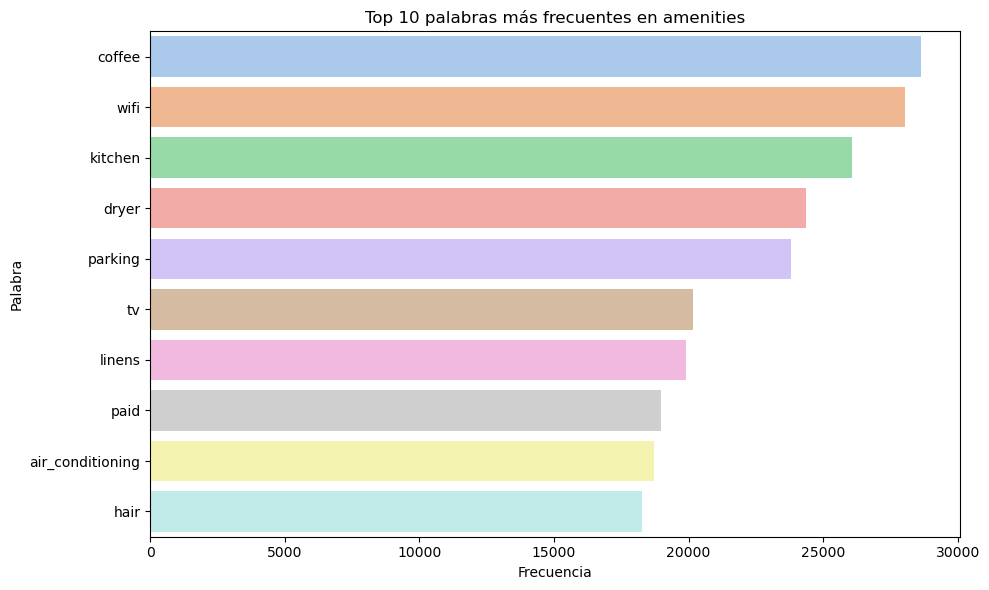

In [587]:
#Creamos un grafico con las palabras y su frecuencia.
plt.figure(figsize=(10, 6))
sns.barplot(data=df_amenities_top_10_words, x='frecuencia', y='palabra', 
            hue='palabra', legend=False, palette='pastel')
plt.title('Top 10 palabras más frecuentes en amenities')
plt.xlabel('Frecuencia')
plt.ylabel('Palabra')
plt.tight_layout()
plt.show()

In [588]:
#Agremamos como columnas (features) las 10 palabras mas frecuentes, agregandose como categoricas nominales (binarias) y eliminando la columna amenities la cual sera redundante.

lista_top_10_servicios = df_amenities_top_10_words["palabra"].tolist()

#Creamos cada palabra del top 10 como columna y verificamos cada muestra si tiene o no dicha caracteristica.
for servicio in lista_top_10_servicios:
    # Si la palabra tiene guion bajo (como air_conditioning), lo cambia por un espacio para buscarlo en el texto original
    termino_busqueda = servicio.replace("_", " ")

    df_3[servicio] = (
        df_3["amenities"]
        .str.contains(termino_busqueda, case=False, na=False)
        .astype("boolean")
    )

#Descartamos la columna amenities
df_3 = df_3.drop(columns=["amenities"]).copy()
df_3

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,coffee,wifi,kitchen,dryer,parking,tv,linens,paid,air_conditioning,hair
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,...,False,True,True,False,False,True,False,False,True,False
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,...,False,True,False,False,True,False,False,True,True,False
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,...,False,True,True,False,False,True,False,False,True,False
3,1004530078359434134,https://www.airbnb.com/rooms/1004530078359434134,20260125052844,2026-01-25,city scrape,Departamento en Recoleta,Relax with the whole family at this peaceful p...,https://a0.muscache.com/pictures/0beb83d5-381d...,1409800,https://www.airbnb.com/users/show/1409800,...,False,True,True,True,False,False,True,False,True,True
4,800145927121871422,https://www.airbnb.com/rooms/800145927121871422,20260125052844,2026-01-25,city scrape,Coqueto para 4 personas,3 rooms: master bedroom with king size bed and...,https://a0.muscache.com/pictures/d2a502bc-2ac0...,467965425,https://www.airbnb.com/users/show/467965425,...,False,True,True,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27343,1587119060096878911,https://www.airbnb.com/rooms/1587119060096878911,20260125052844,2026-01-26,city scrape,Estudio luminoso en el corazón de Villa Crespo.,Comfortable and bright studio in Gurruchaga an...,https://a0.muscache.com/pictures/hosting/Hosti...,1534662,https://www.airbnb.com/users/show/1534662,...,False,True,True,False,False,True,False,False,True,False
27344,37623532,https://www.airbnb.com/rooms/37623532,20260125052844,2026-01-26,city scrape,Modern Top located Duplex Apartment! Up to 4 pax,"This is a Duplex apartment, fully equipped wit...",https://a0.muscache.com/pictures/miso/Hosting-...,2809500,https://www.airbnb.com/users/show/2809500,...,True,True,True,True,True,True,False,True,True,True
27345,1074846345919500333,https://www.airbnb.com/rooms/1074846345919500333,20260125052844,2026-01-26,city scrape,Departamento Villa crespo I,"Beautiful 36 m2 studio apartment, located in a...",https://a0.muscache.com/pictures/hosting/Hosti...,133597828,https://www.airbnb.com/users/show/133597828,...,True,True,True,True,False,True,False,False,True,True
27346,1028342669639305203,https://www.airbnb.com/rooms/1028342669639305203,20260125052844,2026-01-26,city scrape,"Depto a 8 min de Palermo,subte línea B 100 Mts.",Get comfortable and enjoy plenty of extra room...,https://a0.muscache.com/pictures/hosting/Hosti...,49955010,https://www.airbnb.com/users/show/49955010,...,True,True,True,False,True,True,True,True,True,False


### Data wrangling (Datos no explicitos)

Unificamos dos columnas de features **"hosts_time_as_user_months"** y **"hosts_time_as_user_years"**, al igual que **"hosts_time_as_host_months"** y **"hosts_time_as_host_years"** ya que no tiene sentido tener 4 columnas que pueden directamente representarse por 2 en terminos de meses.



In [589]:
df_4 = df_3.copy()
df_4['hosts_time_as_user_months'] = df_4['hosts_time_as_user_years'] * 12 + df_4['hosts_time_as_user_months']
df_4['hosts_time_as_host_months'] = df_4['hosts_time_as_host_years'] * 12 + df_4['hosts_time_as_host_months']
df_4 = df_4.drop(columns=['hosts_time_as_user_years', 'hosts_time_as_host_years'])


### Data wrangling (Agregamos una columna con la comuna a la que pertenece cada barrio para reducir la cantidad de variantes)

Esto puede ser de utilidad tal vez para no tener que manejar un numero tan grande de barrios a la hora de analizar todo el dataset.

In [590]:
# Creamos el diccionario de traducción (Clave: barrio, Valor: comuna)
diccionario_comunas = dict(zip(df_comunas["barrio"], df_comunas["comuna"]))

# Creamos la nueva columna en el dataset de destino usando el mapa
df_4["comuna"] = df_4["neighbourhood_cleansed"].map(diccionario_comunas)
df_4["comuna"] = df_4["comuna"].astype("string")

### VARIABLES LUEGO DE HACER CLEANING Y WRANGLING
* 39 variables numericas
* 39 variables categoricas

In [591]:
#Separamos para evaluar por separado en principio numericas de categoricas

df_numericas = df_4.select_dtypes(include=["Int64", "Float64"])
df_categoricas = df_4.select_dtypes(include=["string", "boolean", "datetime64[ns]"])

print(f"El tamaño del dataset numerico es de {df_numericas.shape[1]} columnas")
print(f"El tamaño del dataset categorico es de {df_categoricas.shape[1]} columnas")

El tamaño del dataset numerico es de 39 columnas
El tamaño del dataset categorico es de 39 columnas


### VARIABLES NUMERICAS
* 26 numericas discretas
* 13 numericas continuas

#### METRICAS DE TENDENCIAS, DISPERSION Y FORMA

Para poder visualizar todas las medidas necesarias vamos a confeccionar una tabla un poco mas completa que solo usando ".info()" donde nos arroje todas las metricas de cada una de las features, para que luego grafiquemos la que necesitemos unicamente mas alla que esten todas calculadas.

In [592]:
columnas_metricas=['media','mediana','moda','skewness','curtosis','varianza','desviacion estandar','Q25', 'Q50', 'Q75', 'IQR']

#Calculamos los cuartiles una sola vez
q25 = df_numericas.quantile(0.25)
q50 = df_numericas.quantile(0.50)
q75 = df_numericas.quantile(0.75)
iqr = q75 - q25

# Construimos la tabla final aplicando las funciones a todas las variables
tabla_resumen_metricas_numericas = pd.DataFrame({
    'media': df_numericas.mean(),
    'mediana': df_numericas.median(),
    'moda': df_numericas.mode().head(1).iloc[0],  
    'skewness': df_numericas.skew(),
    'curtosis': df_numericas.kurt(),
    'varianza': df_numericas.var(),
    'desviacion estandar': df_numericas.std(),
    'Q25': q25,
    'Q50': q50,  
    'Q75': q75,
    'IQR': iqr
}, columns=columnas_metricas)

# Redoundeamos a 2 decimales los valores
tabla_resumen_metricas_numericas = tabla_resumen_metricas_numericas.round(2)
tabla_resumen_metricas_numericas

,media,mediana,moda,skewness,curtosis,varianza,desviacion estandar,Q25,Q50,Q75,IQR
hosts_time_as_user_months,92.44,100.0,144.0,-0.18,-1.05,2280.18,47.75,45.0,100.0,128.0,83.0
hosts_time_as_host_months,66.7,49.0,24.0,0.57,-0.79,2257.7,47.52,28.0,49.0,100.0,72.0
host_listings_count,17.92,3.0,1.0,6.76,109.61,1474.2,38.4,1.0,3.0,16.0,15.0
latitude,-34.59,-34.59,-34.59,0.01,0.4,0.0,0.02,-34.6,-34.59,-34.58,0.02
longitude,-58.42,-58.42,-58.39,-0.34,-0.22,0.0,0.03,-58.44,-58.42,-58.39,0.04
accommodates,2.95,2.0,2.0,3.05,17.36,2.45,1.57,2.0,2.0,4.0,2.0
bathrooms,1.23,1.0,1.0,8.61,154.65,0.46,0.67,1.0,1.0,1.0,0.0
bedrooms,1.16,1.0,1.0,4.69,54.23,0.83,0.91,1.0,1.0,1.0,0.0
beds,1.9,1.0,1.0,5.01,62.18,2.32,1.52,1.0,1.0,2.0,1.0
minimum_nights,4.75,2.0,1.0,18.27,496.86,270.09,16.43,1.0,2.0,3.0,2.0


skewness: 3.28
curtosis: 18.33
varianza: 3145.26
desviacion estandar: 56.08


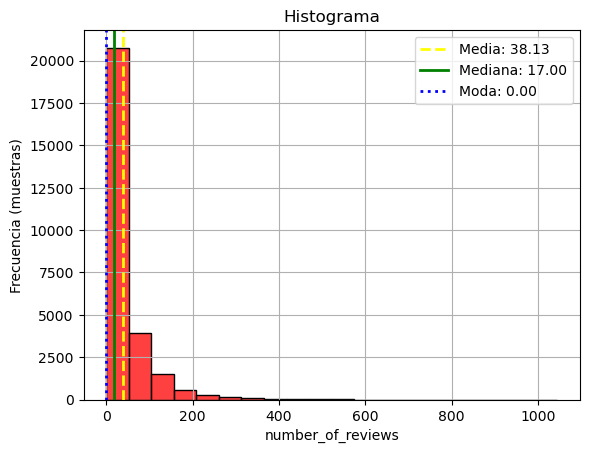

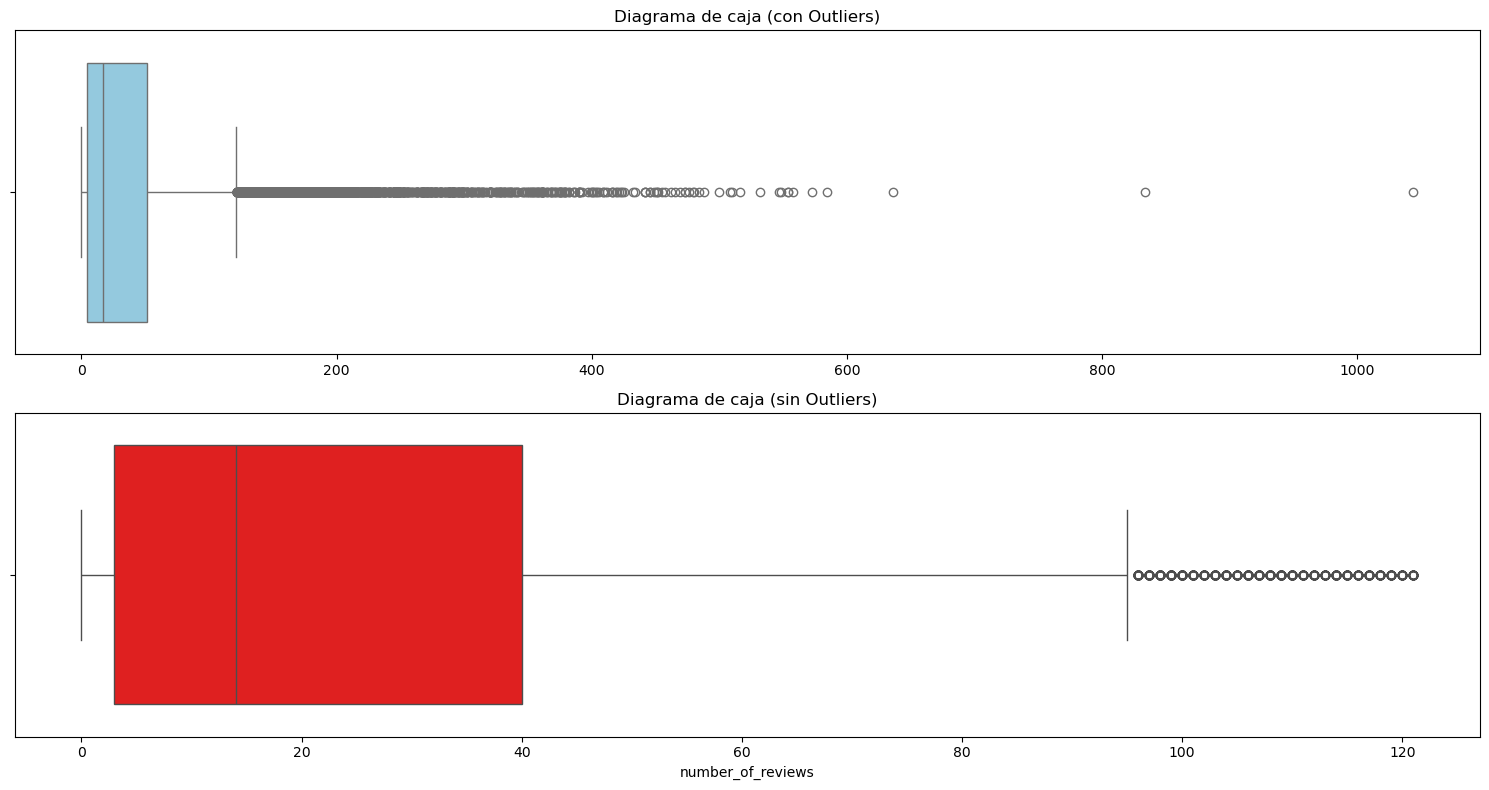

In [593]:
#Ingresamos nombre de feature que queremos graficar tanto su histograma como su diagrama de caja.
columna_seleccionada = "number_of_reviews"

#GRAFICO DE HISTOGRAMA

#Definimos las metricas en variables
media = tabla_resumen_metricas_numericas.loc[columna_seleccionada,"media"]
mediana = tabla_resumen_metricas_numericas.loc[columna_seleccionada,"mediana"]
moda = tabla_resumen_metricas_numericas.loc[columna_seleccionada,"moda"]

print(f'skewness: {tabla_resumen_metricas_numericas.loc[columna_seleccionada,"skewness"]}')
print(f'curtosis: {tabla_resumen_metricas_numericas.loc[columna_seleccionada,"curtosis"]}')
print(f'varianza: {tabla_resumen_metricas_numericas.loc[columna_seleccionada,"varianza"]}')
print(f'desviacion estandar: {tabla_resumen_metricas_numericas.loc[columna_seleccionada,"desviacion estandar"]}')

# Generamos un histograma
sns.histplot(data=df, x=columna_seleccionada, bins=20, color='red')

#Se agregan las medidas de tendencia
plt.axvline(x=media, color='yellow', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(x=mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(x=moda, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

# Asignamos los nombres a los ejes y el titulo
plt.title('Histograma')
plt.xlabel(columna_seleccionada)
plt.ylabel('Frecuencia (muestras)')
plt.grid(True)
plt.legend() 
plt.show()

#GRAFICO DE DIAGRAMA DE CAJA

# Límites teóricos para detectar outliers
limite_inferior = tabla_resumen_metricas_numericas.loc[columna_seleccionada,"Q25"] - 1.5 * tabla_resumen_metricas_numericas.loc[columna_seleccionada,"IQR"]
limite_superior = tabla_resumen_metricas_numericas.loc[columna_seleccionada,"Q75"] + 1.5 * tabla_resumen_metricas_numericas.loc[columna_seleccionada,"IQR"]


# Generamos una figura con dos graficos en una columna, sin restringir el eje X porque hay muchos outliers.
fig, ax = plt.subplots(2, 1, figsize=(15, 8))

# Definimos los datos del primer grafico "ax[0]" el cual incluye los outliers.
sns.boxplot(
    data=df, 
    x=columna_seleccionada,
    ax=ax[0], 
    color='skyblue'
)


ax[0].set_title('Diagrama de caja (con Outliers)')
ax[0].set_xlabel('')

# Definimos los datos del segundo grafico "ax[1]" el cual no incluye los outliers.
df_filtrado = df_numericas[df_numericas[columna_seleccionada].between(limite_inferior, limite_superior)]

sns.boxplot(
    data=df_filtrado, 
    x=columna_seleccionada, 
    ax=ax[1], 
    color='red'
)

ax[1].set_title('Diagrama de caja (sin Outliers)')
ax[1].set_xlabel(columna_seleccionada)

plt.tight_layout()
plt.show()

#### RELACION ENTRE VARIABLES NUMERICAS

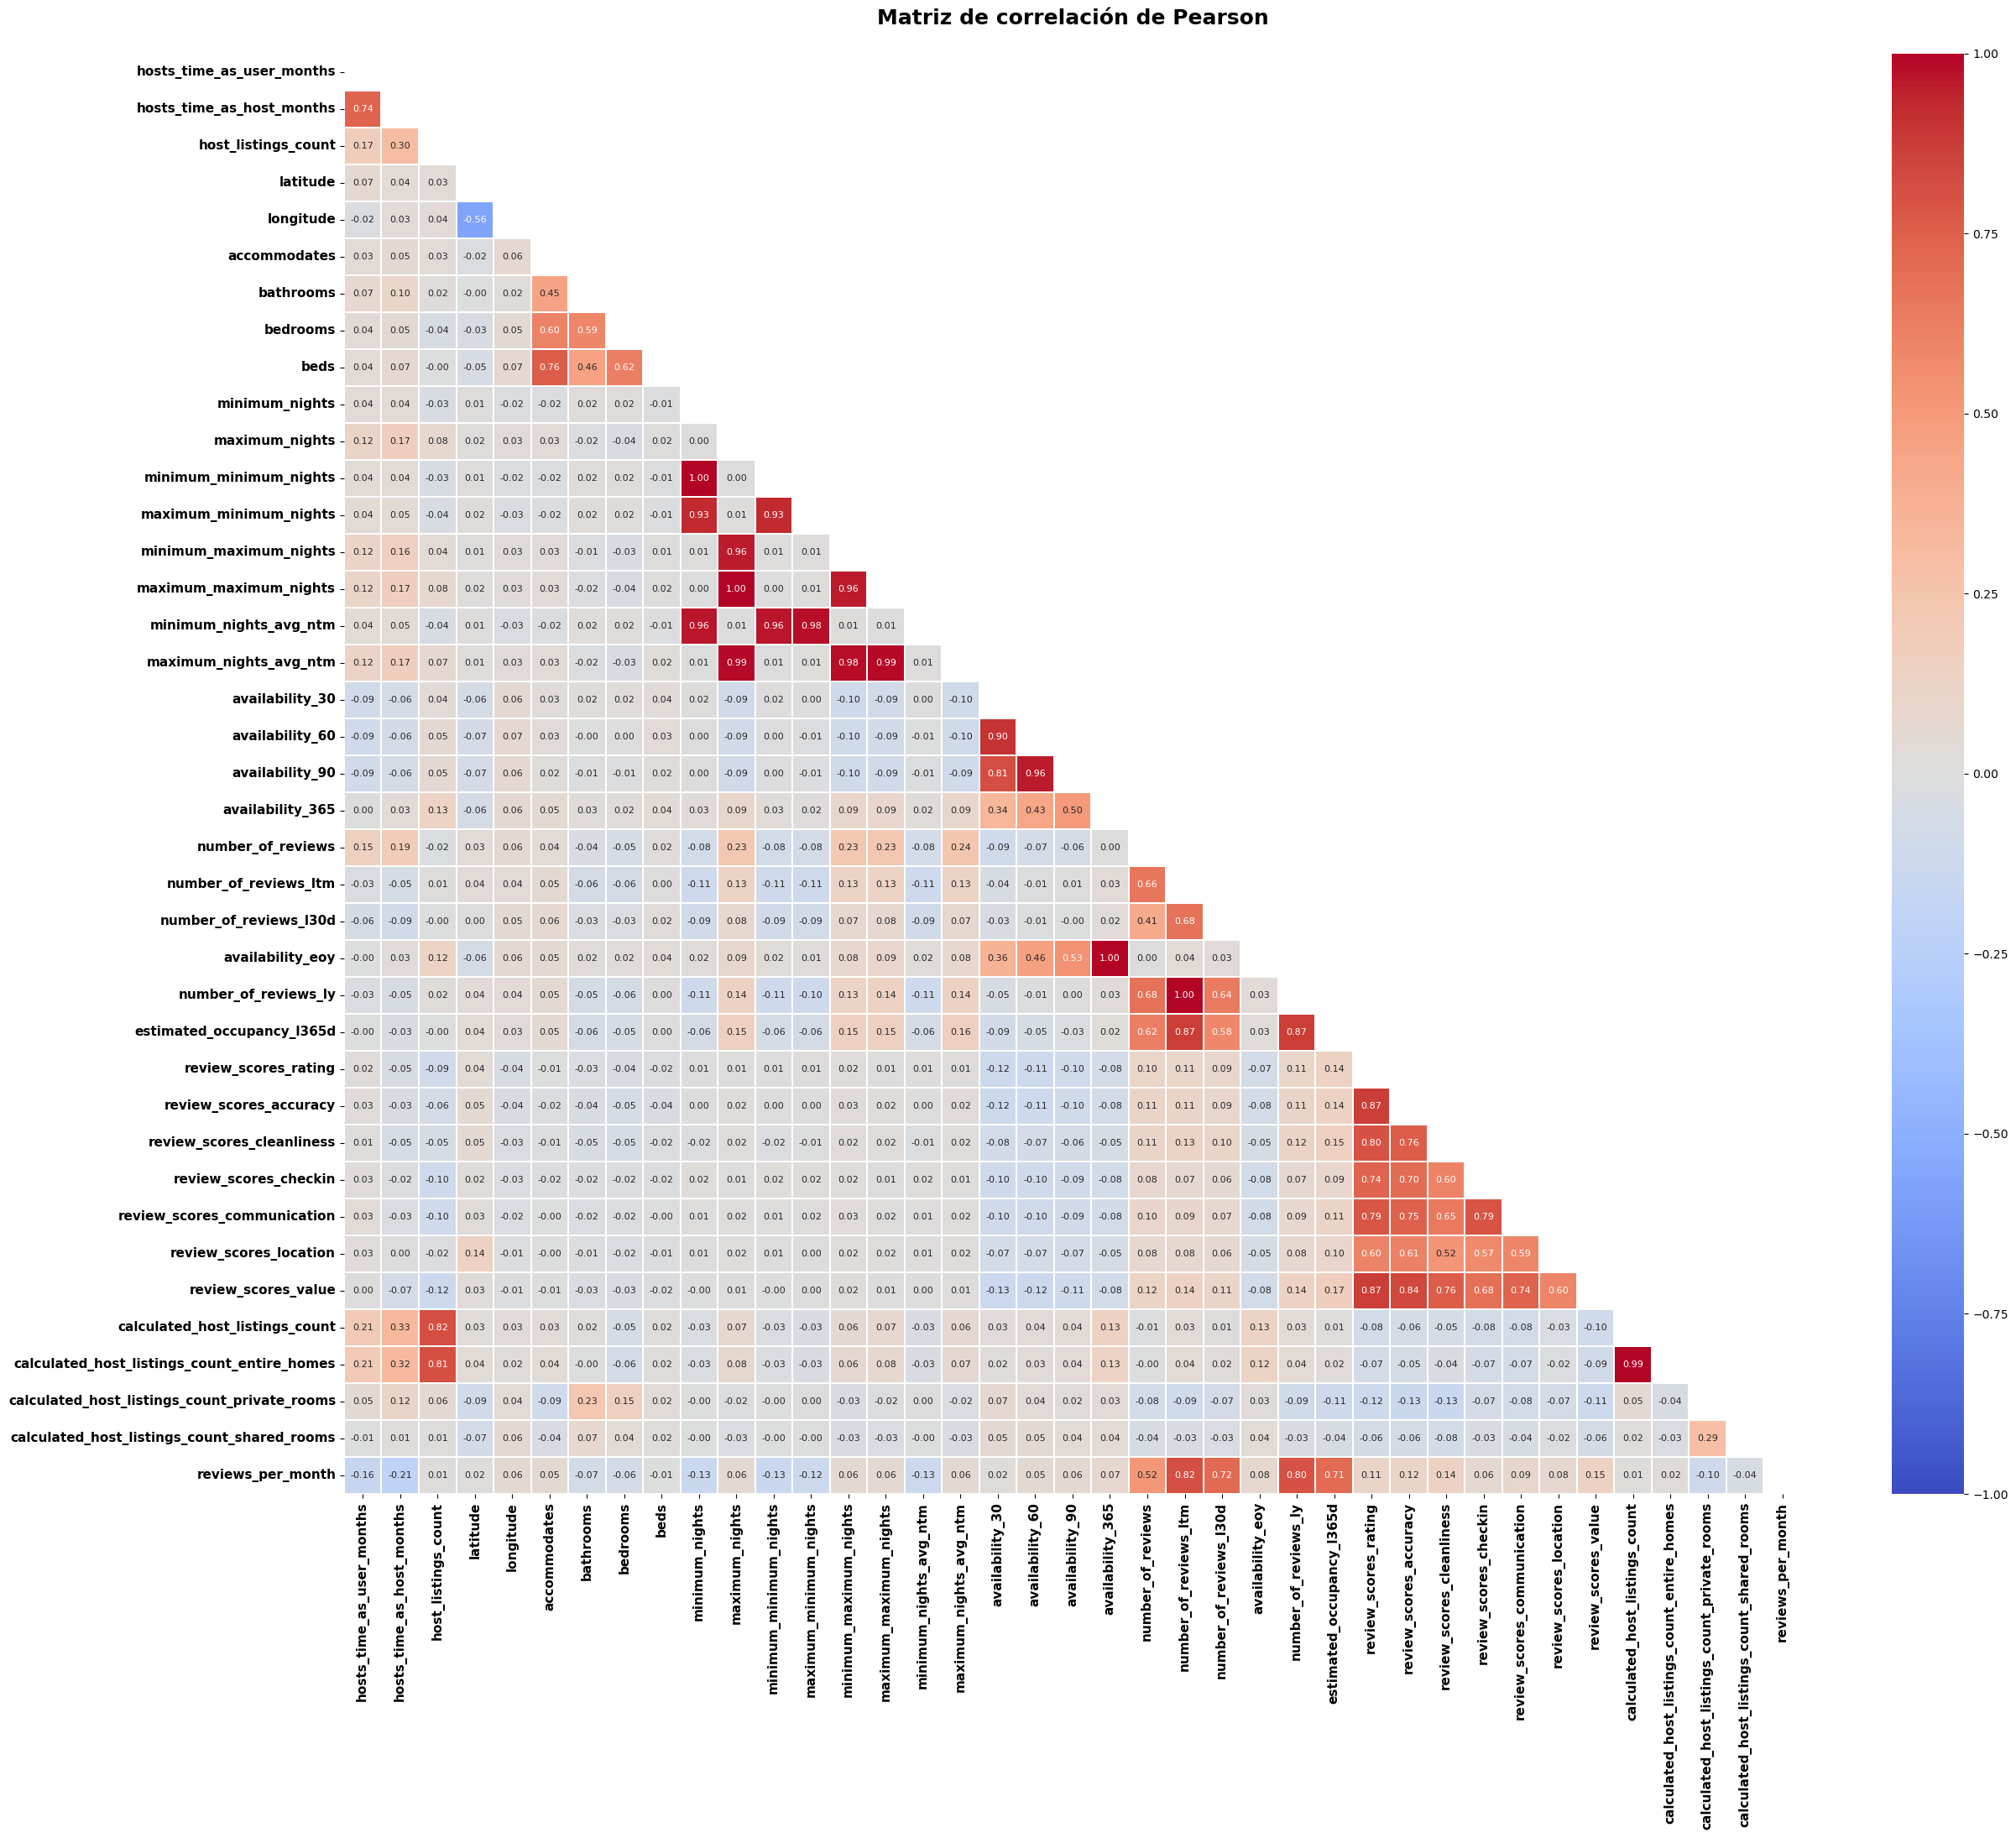

In [594]:
display(
    HTML(
        "<div style='max-height: 650px; max-width: 100%; overflow: auto; border: 2px solid #ccc; border-radius: 4px;'>"
    )
)

# Definimos un tamaño de lienzo interno para que los textos no se encimen
plt.figure(figsize=(26, 22))

# Calculamos la matriz de Pearson y ocultamos la mitad superior repetida
matriz_completa = df_numericas.corr(method="pearson")
mascara = np.triu(np.ones_like(matriz_completa, dtype=bool))

# Dibujar el Heatmap
sns.heatmap(
    matriz_completa,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3,
    annot_kws={"size": 8},
    vmin=-1,
    vmax=1,
)

# Configuramos tipografias y titulos legibles
plt.xticks(rotation=90, fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.title(
    "Matriz de correlación de Pearson",
    fontsize=18,
    weight="bold",
    pad=25,
)
plt.tight_layout()

# Renderizar el grafico dentro del contenedor y cerrar el bloque HTML
plt.show()
display(HTML("</div>"))

# Libera la memoria RAM inmediatamente para que la notebook no se vuelva lenta
plt.close()

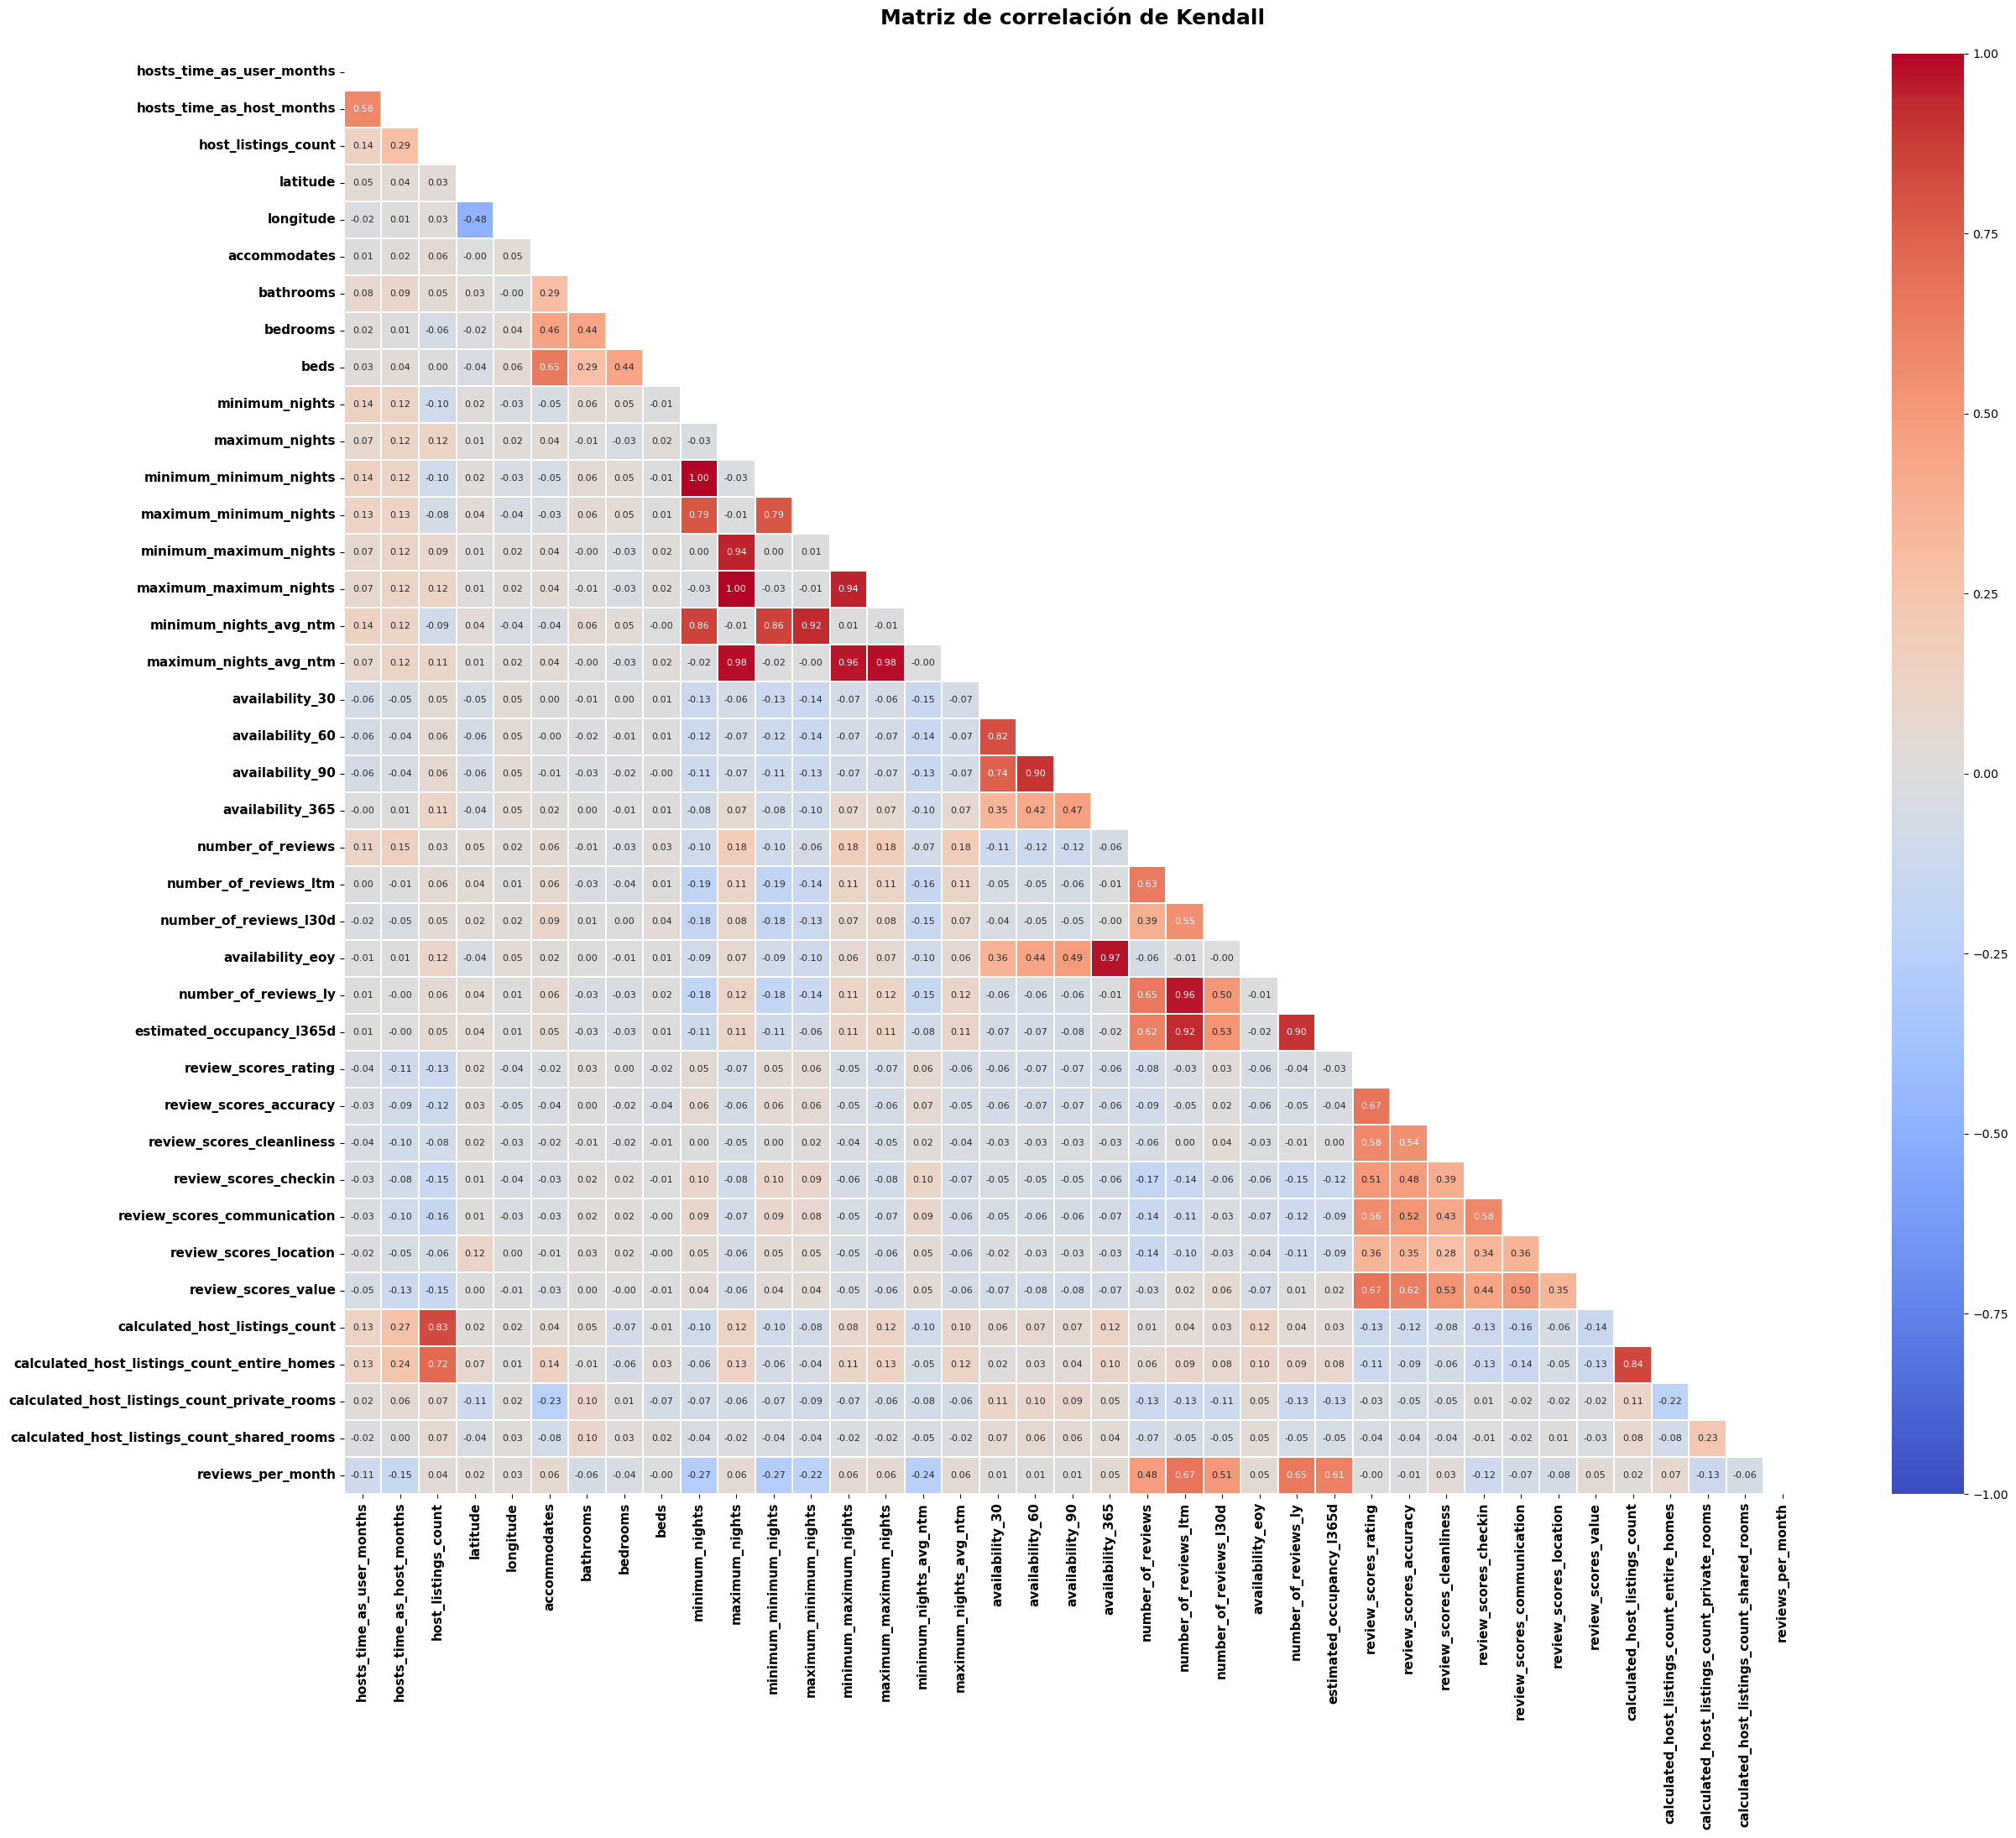

In [595]:
display(
    HTML(
        "<div style='max-height: 650px; max-width: 100%; overflow: auto; border: 2px solid #ccc; border-radius: 4px;'>"
    )
)

# Definimos un tamaño de lienzo interno para que los textos no se encimen
plt.figure(figsize=(26, 22))

# Calculamos la matriz de Pearson y ocultamos la mitad superior repetida
matriz_completa = df_numericas.corr(method="kendall")
mascara = np.triu(np.ones_like(matriz_completa, dtype=bool))

# Dibujar el Heatmap
sns.heatmap(
    matriz_completa,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3,
    annot_kws={"size": 8},
    vmin=-1,
    vmax=1,
)

# Configuramos tipografias y titulos legibles
plt.xticks(rotation=90, fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.title(
    "Matriz de correlación de Kendall",
    fontsize=18,
    weight="bold",
    pad=25,
)
plt.tight_layout()

# Renderizar el grafico dentro del contenedor y cerrar el bloque HTML
plt.show()
display(HTML("</div>"))

# Libera la memoria RAM inmediatamente para que la notebook no se vuelva lenta
plt.close()

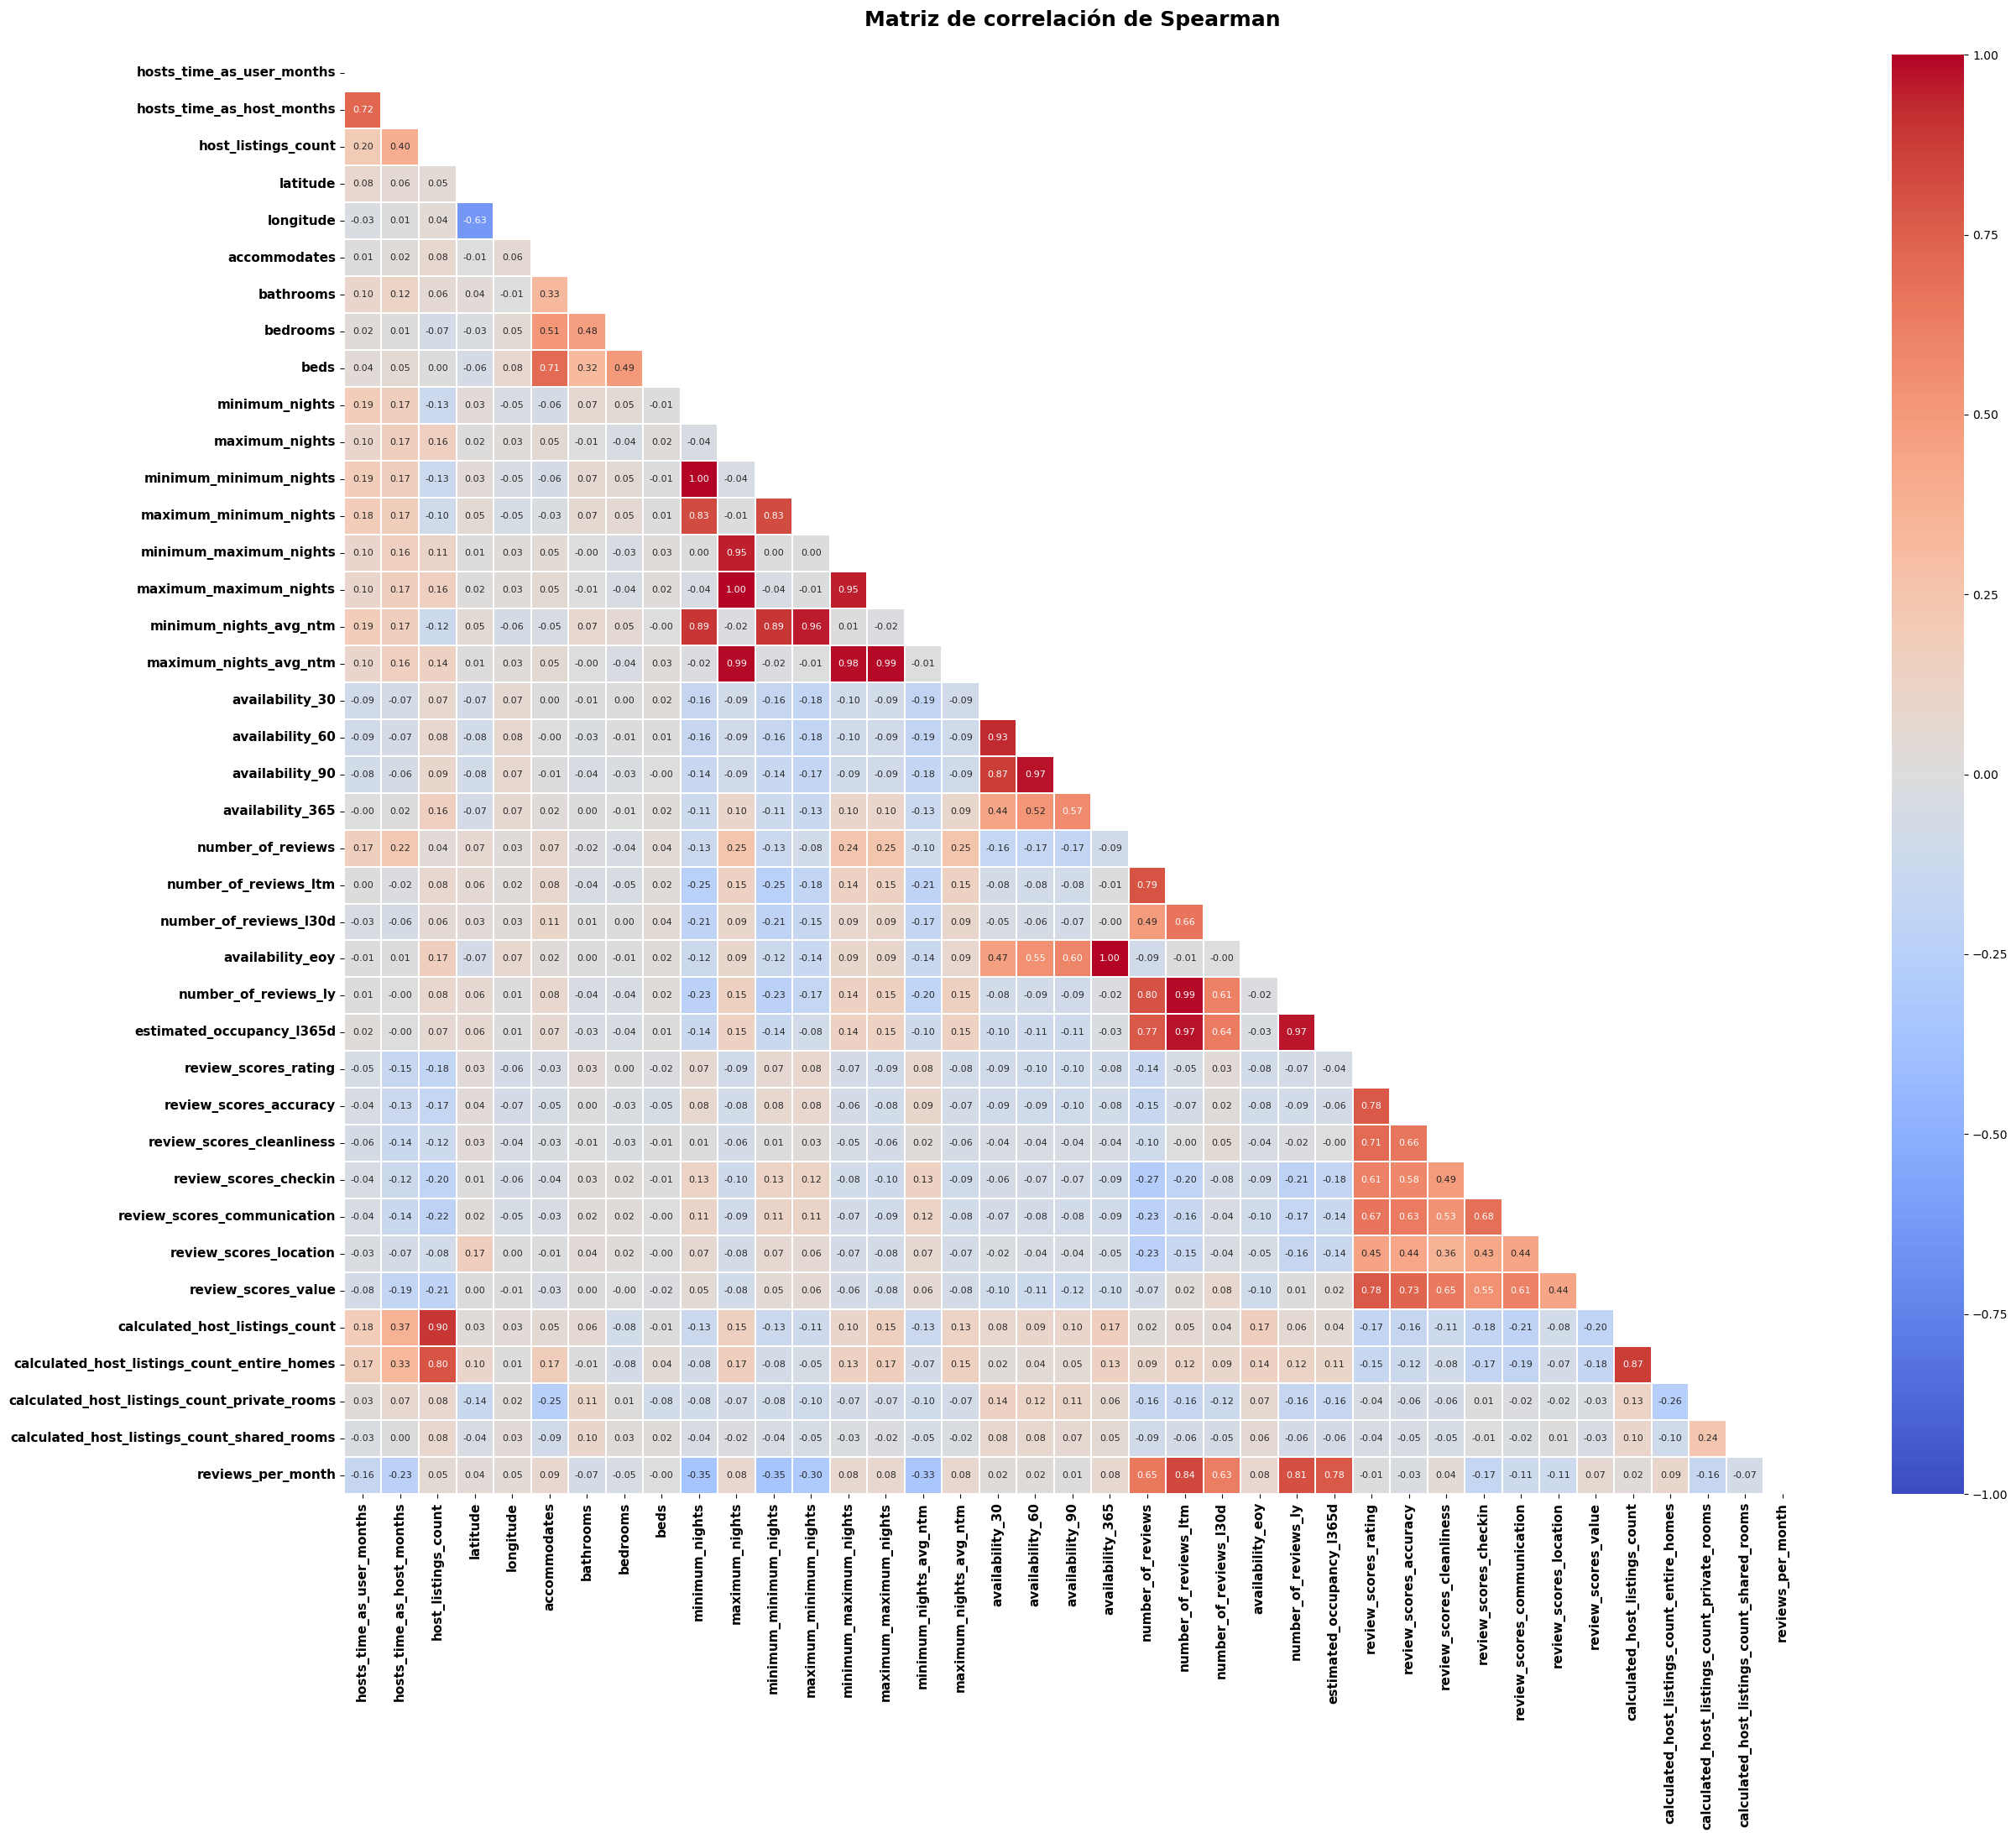

In [596]:
display(
    HTML(
        "<div style='max-height: 650px; max-width: 100%; overflow: auto; border: 2px solid #ccc; border-radius: 4px;'>"
    )
)

# Definimos un tamaño de lienzo interno para que los textos no se encimen
plt.figure(figsize=(26, 22))

# Calculamos la matriz de Pearson y ocultamos la mitad superior repetida
matriz_completa = df_numericas.corr(method="spearman")
mascara = np.triu(np.ones_like(matriz_completa, dtype=bool))

# Dibujar el Heatmap
sns.heatmap(
    matriz_completa,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3,
    annot_kws={"size": 8},
    vmin=-1,
    vmax=1,
)

# Configuramos tipografias y titulos legibles
plt.xticks(rotation=90, fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.title(
    "Matriz de correlación de Spearman",
    fontsize=18,
    weight="bold",
    pad=25,
)
plt.tight_layout()

# Renderizar el grafico dentro del contenedor y cerrar el bloque HTML
plt.show()
display(HTML("</div>"))

# Libera la memoria RAM inmediatamente para que la notebook no se vuelva lenta
plt.close()

### VARIABLES CATEGORICAS
* 35 categoricas nominales
* 4 categoricas ordinales

In [597]:
#Creamos un dataframe con un resumen de metricas utiles para variables categoricas.
tabla_resumen_metricas_categoricas = pd.DataFrame({
    'Cardinalidad (Categorias unicas)': df_categoricas.nunique(),
    'Moda': df_categoricas.mode().iloc[0],
    'Frecuencia absoluta moda': [df_categoricas[col].value_counts().max() for col in df_categoricas.columns],
    'Frecuencia relativa moda (%)': [round((df_categoricas[col].value_counts(normalize=True).max() * 100), 2) for col in df_categoricas.columns],
    'Frecuencias total de feature': [df_categoricas[col].count() for col in df_categoricas.columns]
})

tabla_resumen_metricas_categoricas


,Cardinalidad (Categorias unicas),Moda,Frecuencia absoluta moda,Frecuencia relativa moda (%),Frecuencias total de feature
id,27348,1000043599728796614,1,0.00,27348
listing_url,27348,https://www.airbnb.com/rooms/1000043599728796614,1,0.00,27348
scrape_id,1,20260125052844,27348,100.00,27348
last_scraped,2,2026-01-25 00:00:00,14113,51.61,27348
source,1,city scrape,27348,100.00,27348
name,25865,Departamento en Buenos Aires,69,0.25,27348
description,23703,Keep it simple at this peaceful and centrally-...,133,0.50,26752
picture_url,26848,https://a0.muscache.com/pictures/miso/Hosting-...,12,0.04,27347
host_id,14355,3469227,188,0.69,27348
host_url,14355,https://www.airbnb.com/users/show/3469227,188,0.69,27348


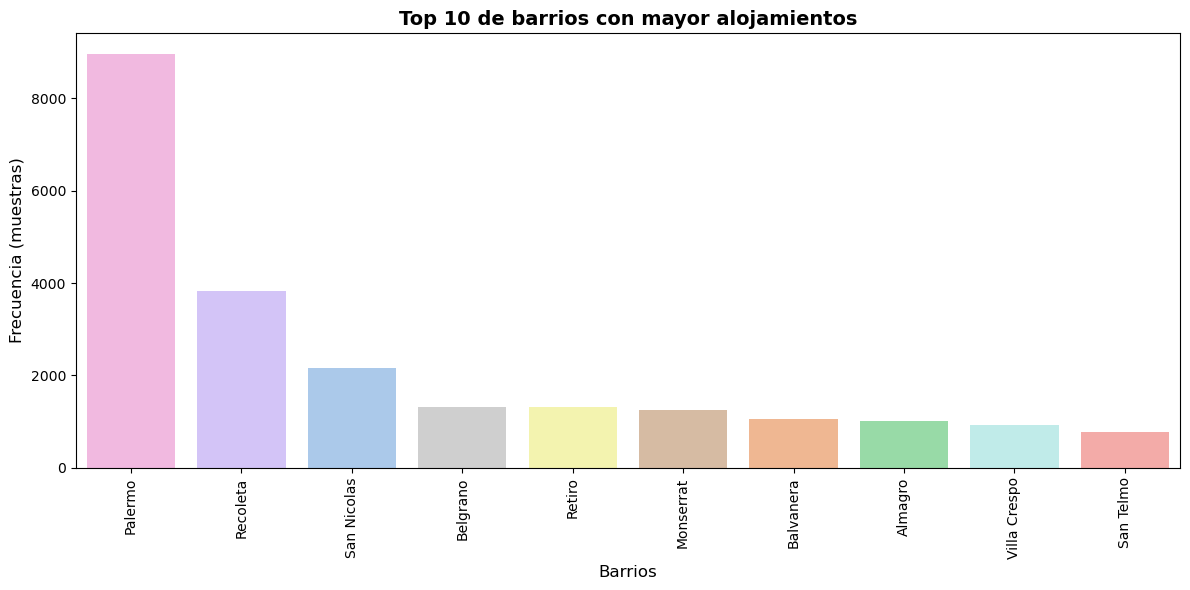

In [598]:
#GRAFICO DE TOP 10 DE BARRIOS CON MAYOR ALOJAMIENTOS

#Filtramos el top 10 cde barrios con mas cantidad de anuncios
top_10_barrios = df_categoricas['neighbourhood_cleansed'].value_counts().iloc[:10].index

# Configuramos el tamaño
plt.figure(figsize=(12, 6))

# Creamos el gráfico de barras verticales ordenado
sns.countplot(
    x='neighbourhood_cleansed', 
    data=df_categoricas[df_categoricas['neighbourhood_cleansed'].isin(top_10_barrios)], 
    order=top_10_barrios, 
    palette='pastel',
    hue='neighbourhood_cleansed',     
    legend=False  
)

# Rotamos los nombres de los barrios 90 grados para que no se encimen
plt.xticks(rotation=90)

# Personalizamos los títulos y etiquetas del gráfico
plt.title('Top 10 de barrios con mayor alojamientos', fontsize=14, fontweight='bold')
plt.xlabel('Barrios', fontsize=12)
plt.ylabel('Frecuencia (muestras)', fontsize=12)

# Ajustamos el diseño y mostramos el gráfico
plt.tight_layout()
plt.show()


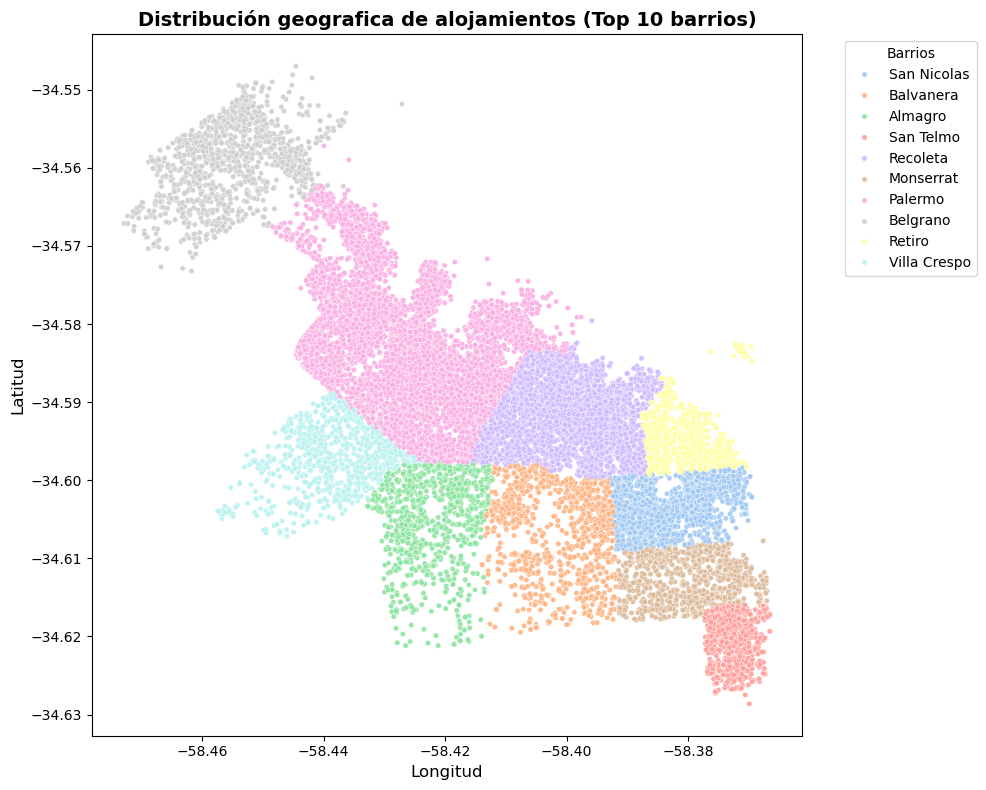

In [599]:
#GRAFICO DE DISTRIBUCION CON LATITUD Y LONGITUD DE ALOJAMIENTOS POR BARRIO

# Configuramos el tamaño
plt.figure(figsize=(10, 8))

# Filtramos el DataFrame para que solo grafique los alojamientos del top 10 de barrios
df_top_barrios = df_categoricas[df_categoricas['neighbourhood_cleansed'].isin(top_10_barrios)]

# Creamos el scatterplot geográfico
sns.scatterplot(
    x='longitude',                  
    y='latitude',                   
    hue='neighbourhood_cleansed',   
    data=df[df['neighbourhood_cleansed'].isin(top_10_barrios)],
    palette='pastel',               
    alpha=0.9,                      
    s=15                            
)

# Personalizamos títulos y ejes
plt.title('Distribución geografica de alojamientos (Top 10 barrios)', fontsize=14, fontweight='bold')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Colocamos la leyenda de los barrios fuera del gráfico para que no estorbe
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Barrios')

# Ajustamos diseño y mostramos
plt.tight_layout()
plt.show()


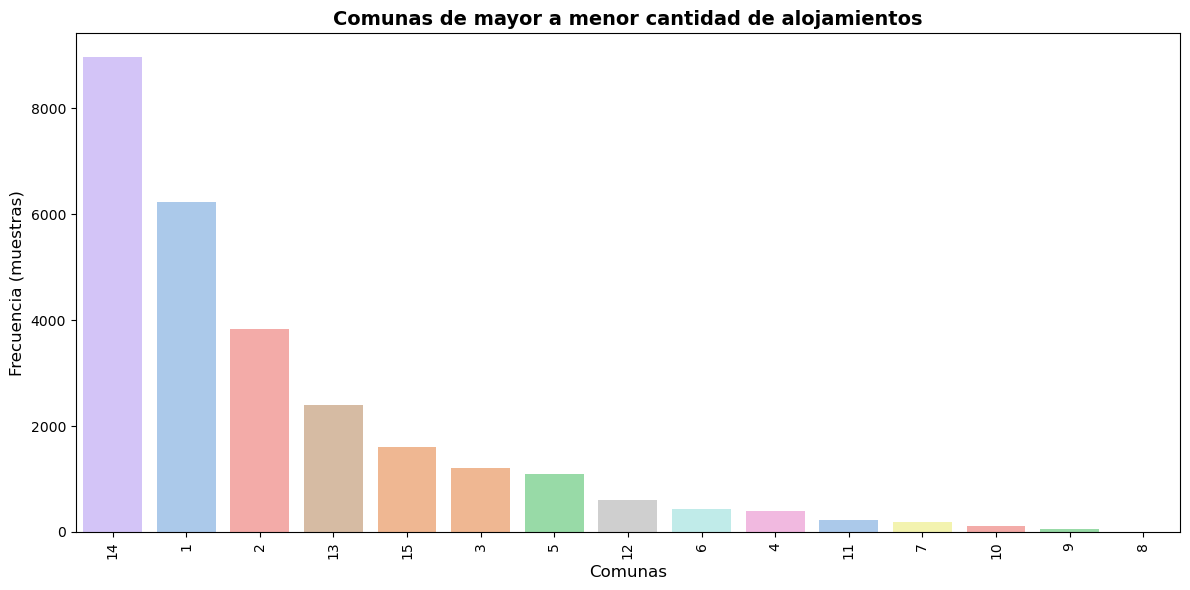

In [600]:
#GRAFICO DE COMUNAS ORDENADAS DE MAYOR A MENOR CANTIDAD DE ALOJAMIENTOS

# Configuramos el tamaño
plt.figure(figsize=(12, 6))

# Calcula el orden de las comunas de mayor a menor frecuencia
orden_comunas = df_categoricas['comuna'].value_counts().index

# Creamos el gráfico de barras verticales ordenado
sns.countplot(
    x='comuna', 
    data=df_categoricas, 
    order=orden_comunas, 
    palette='pastel',
    hue='comuna',     
    legend=False  
)

# Rotamos los nombres de los barrios 90 grados para que no se encimen
plt.xticks(rotation=90)

# Personalizamos los títulos y etiquetas del gráfico
plt.title('Comunas de mayor a menor cantidad de alojamientos', fontsize=14, fontweight='bold')
plt.xlabel('Comunas', fontsize=12)
plt.ylabel('Frecuencia (muestras)', fontsize=12)

# Ajustamos el diseño y mostramos el gráfico
plt.tight_layout()
plt.show()

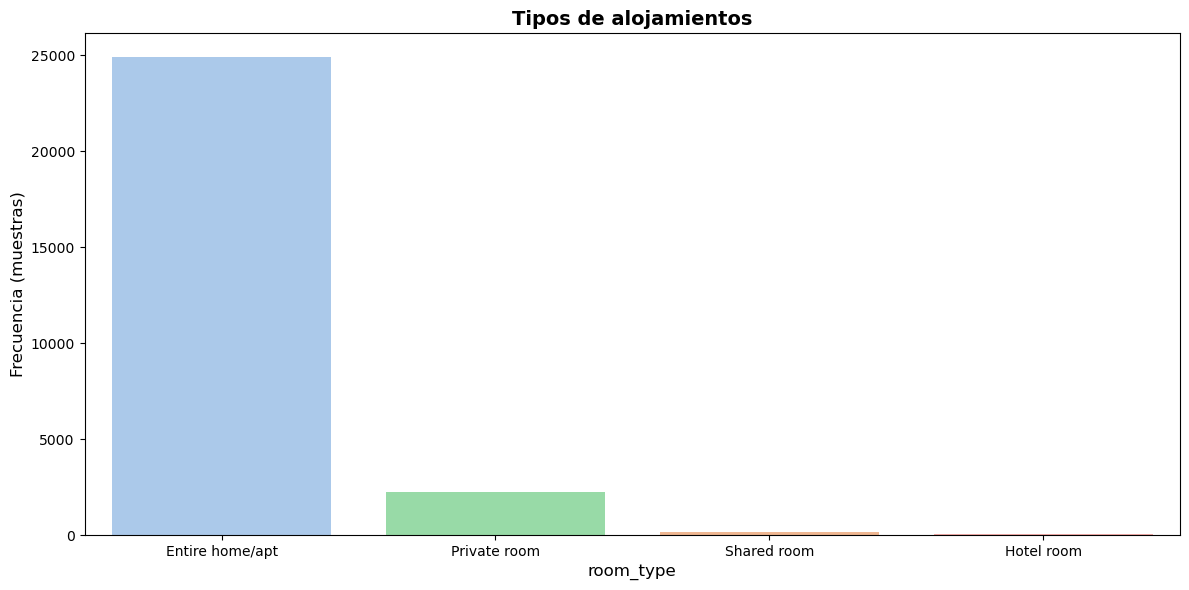

In [601]:
#GRAFICO DE TIPOS DE ALOJAMIENTO ORDENADOS DE MAYOR FRECUENCIA A MENOR

# Configuramos el tamaño
plt.figure(figsize=(12, 6))

# Calcula el orden de las comunas de mayor a menor frecuencia
orden_room_type = df_categoricas['room_type'].value_counts().index

# Creamos el gráfico de barras verticales ordenado
sns.countplot(
    x='room_type', 
    data=df_categoricas, 
    order=orden_room_type, 
    palette='pastel',
    hue='room_type',     
    legend=False  
)

# Rotamos los nombres de los barrios 90 grados para que no se encimen
plt.xticks(rotation=0)

# Personalizamos los títulos y etiquetas del gráfico
plt.title('Tipos de alojamientos', fontsize=14, fontweight='bold')
plt.xlabel('room_type', fontsize=12)
plt.ylabel('Frecuencia (muestras)', fontsize=12)

# Ajustamos el diseño y mostramos el gráfico
plt.tight_layout()
plt.show()

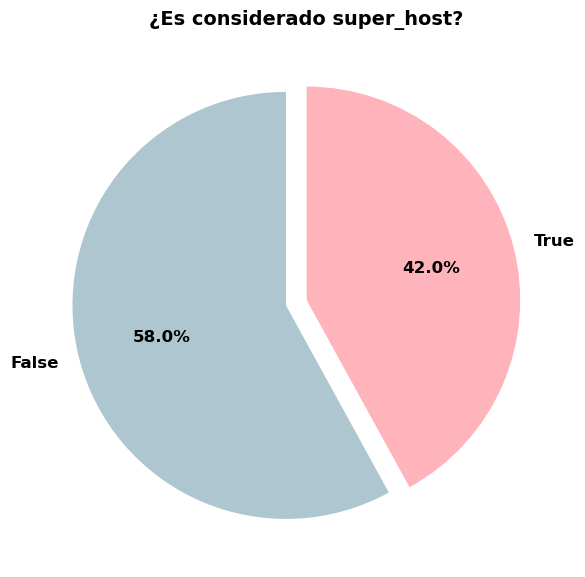

In [602]:
#GRAFICO DE TORTA QUE REPRESENTA DE LA TOTALIDAD DE MUESTRAS QUE PORCENTAJE ES SUPERHOST 

# Preparamos los datos de la variable binaria a evaluar
frecuencias = df_categoricas['host_is_superhost'].value_counts()

# Separamos (explode) automáticamente solo la porción más grande
explode = [0.1 if v == frecuencias.max() else 0 for v in frecuencias]

# Configuramos el tamaño de la imagen y los colores
plt.figure(figsize=(6, 6))
colores = ['#aec6cf', '#ffb3ba']  # Azul pastel y rosa pastel

# Parametrizamos el grafico circular
plt.pie(
    frecuencias, 
    labels=frecuencias.index,          # Nombres de las dos opciones
    explode=explode,                  # Resalta la porción mayor
    autopct='%1.1f%%',                # Muestra los porcentajes adentro automáticamente
    pctdistance=0.6,                  # Controla qué tan centrados quedan los porcentajes internos
    startangle=90,                    # Alineación vertical limpia
    colors=colores[:len(frecuencias)],
    textprops={'fontsize': 12, 'weight': 'bold'}  # Estilo de texto para todo el gráfico
)

# Definimos titulo y mostramos el grafico
plt.title('¿Es considerado super_host?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

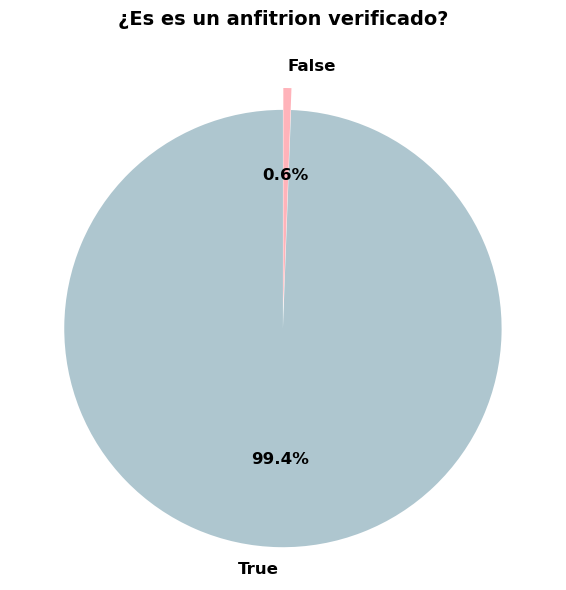

In [603]:
#GRAFICO DE TORTA QUE REPRESENTA DE LA TOTALIDAD DE MUESTRAS QUE PORCENTAJE DE ANFITRIONES TIENE LA IDENTIDAD VERIFICADA 

# Preparamos los datos de la variable binaria a evaluar
frecuencias = df_categoricas['host_identity_verified'].value_counts()

# Separamos (explode) automáticamente solo la porción más grande
explode = [0.1 if v == frecuencias.max() else 0 for v in frecuencias]

# Configuramos el tamaño de la imagen y los colores
plt.figure(figsize=(6, 6))
colores = ['#aec6cf', '#ffb3ba']  # Azul pastel y rosa pastel

# Parametrizamos el grafico circular
plt.pie(
    frecuencias, 
    labels=frecuencias.index,          # Nombres de las dos opciones
    explode=explode,                  # Resalta la porción mayor
    autopct='%1.1f%%',                # Muestra los porcentajes adentro automáticamente
    pctdistance=0.6,                  # Controla qué tan centrados quedan los porcentajes internos
    startangle=90,                    # Alineación vertical limpia
    colors=colores[:len(frecuencias)],
    textprops={'fontsize': 12, 'weight': 'bold'}  # Estilo de texto para todo el gráfico
)

# Definimos titulo y mostramos el grafico
plt.title('¿Es es un anfitrion verificado?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

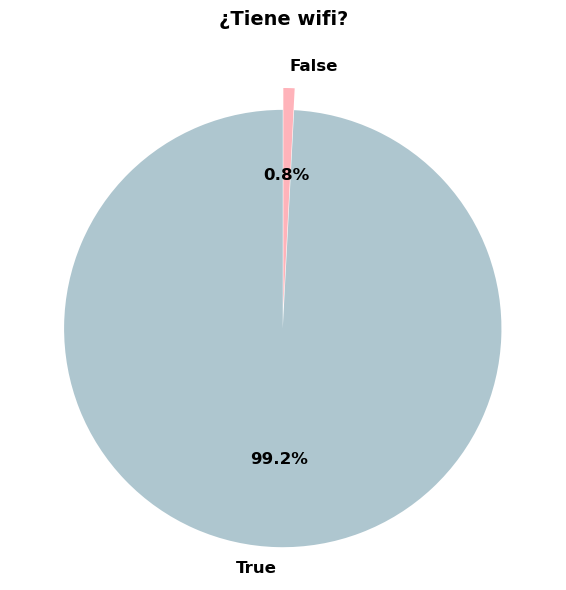

In [604]:
#GRAFICO DE TORTA QUE REPRESENTA DE LA TOTALIDAD DE MUESTRAS QUE PORCENTAJE TIENE WIFI

# Preparamos los datos de la variable binaria a evaluar
frecuencias = df_categoricas['wifi'].value_counts()

# Separamos (explode) automáticamente solo la porción más grande
explode = [0.1 if v == frecuencias.max() else 0 for v in frecuencias]

# Configuramos el tamaño de la imagen y los colores
plt.figure(figsize=(6, 6))
colores = ['#aec6cf', '#ffb3ba']  # Azul pastel y rosa pastel

# Parametrizamos el grafico circular
plt.pie(
    frecuencias, 
    labels=frecuencias.index,          # Nombres de las dos opciones
    explode=explode,                  # Resalta la porción mayor
    autopct='%1.1f%%',                # Muestra los porcentajes adentro automáticamente
    pctdistance=0.6,                  # Controla qué tan centrados quedan los porcentajes internos
    startangle=90,                    # Alineación vertical limpia
    colors=colores[:len(frecuencias)],
    textprops={'fontsize': 12, 'weight': 'bold'}  # Estilo de texto para todo el gráfico
)

# Definimos titulo y mostramos el grafico
plt.title('¿Tiene wifi?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### RELACION ENTRE VARIABLES CATEGORICAS

Vamos a analizar si existe alguna correlacion entre algunas variables **"categoricas binarias"**, por lo que vamos a realizar una matriz de correlación categorica utilizando el **coeficiente phi**, volcando los resultados en un mapa de calor (heatmap).

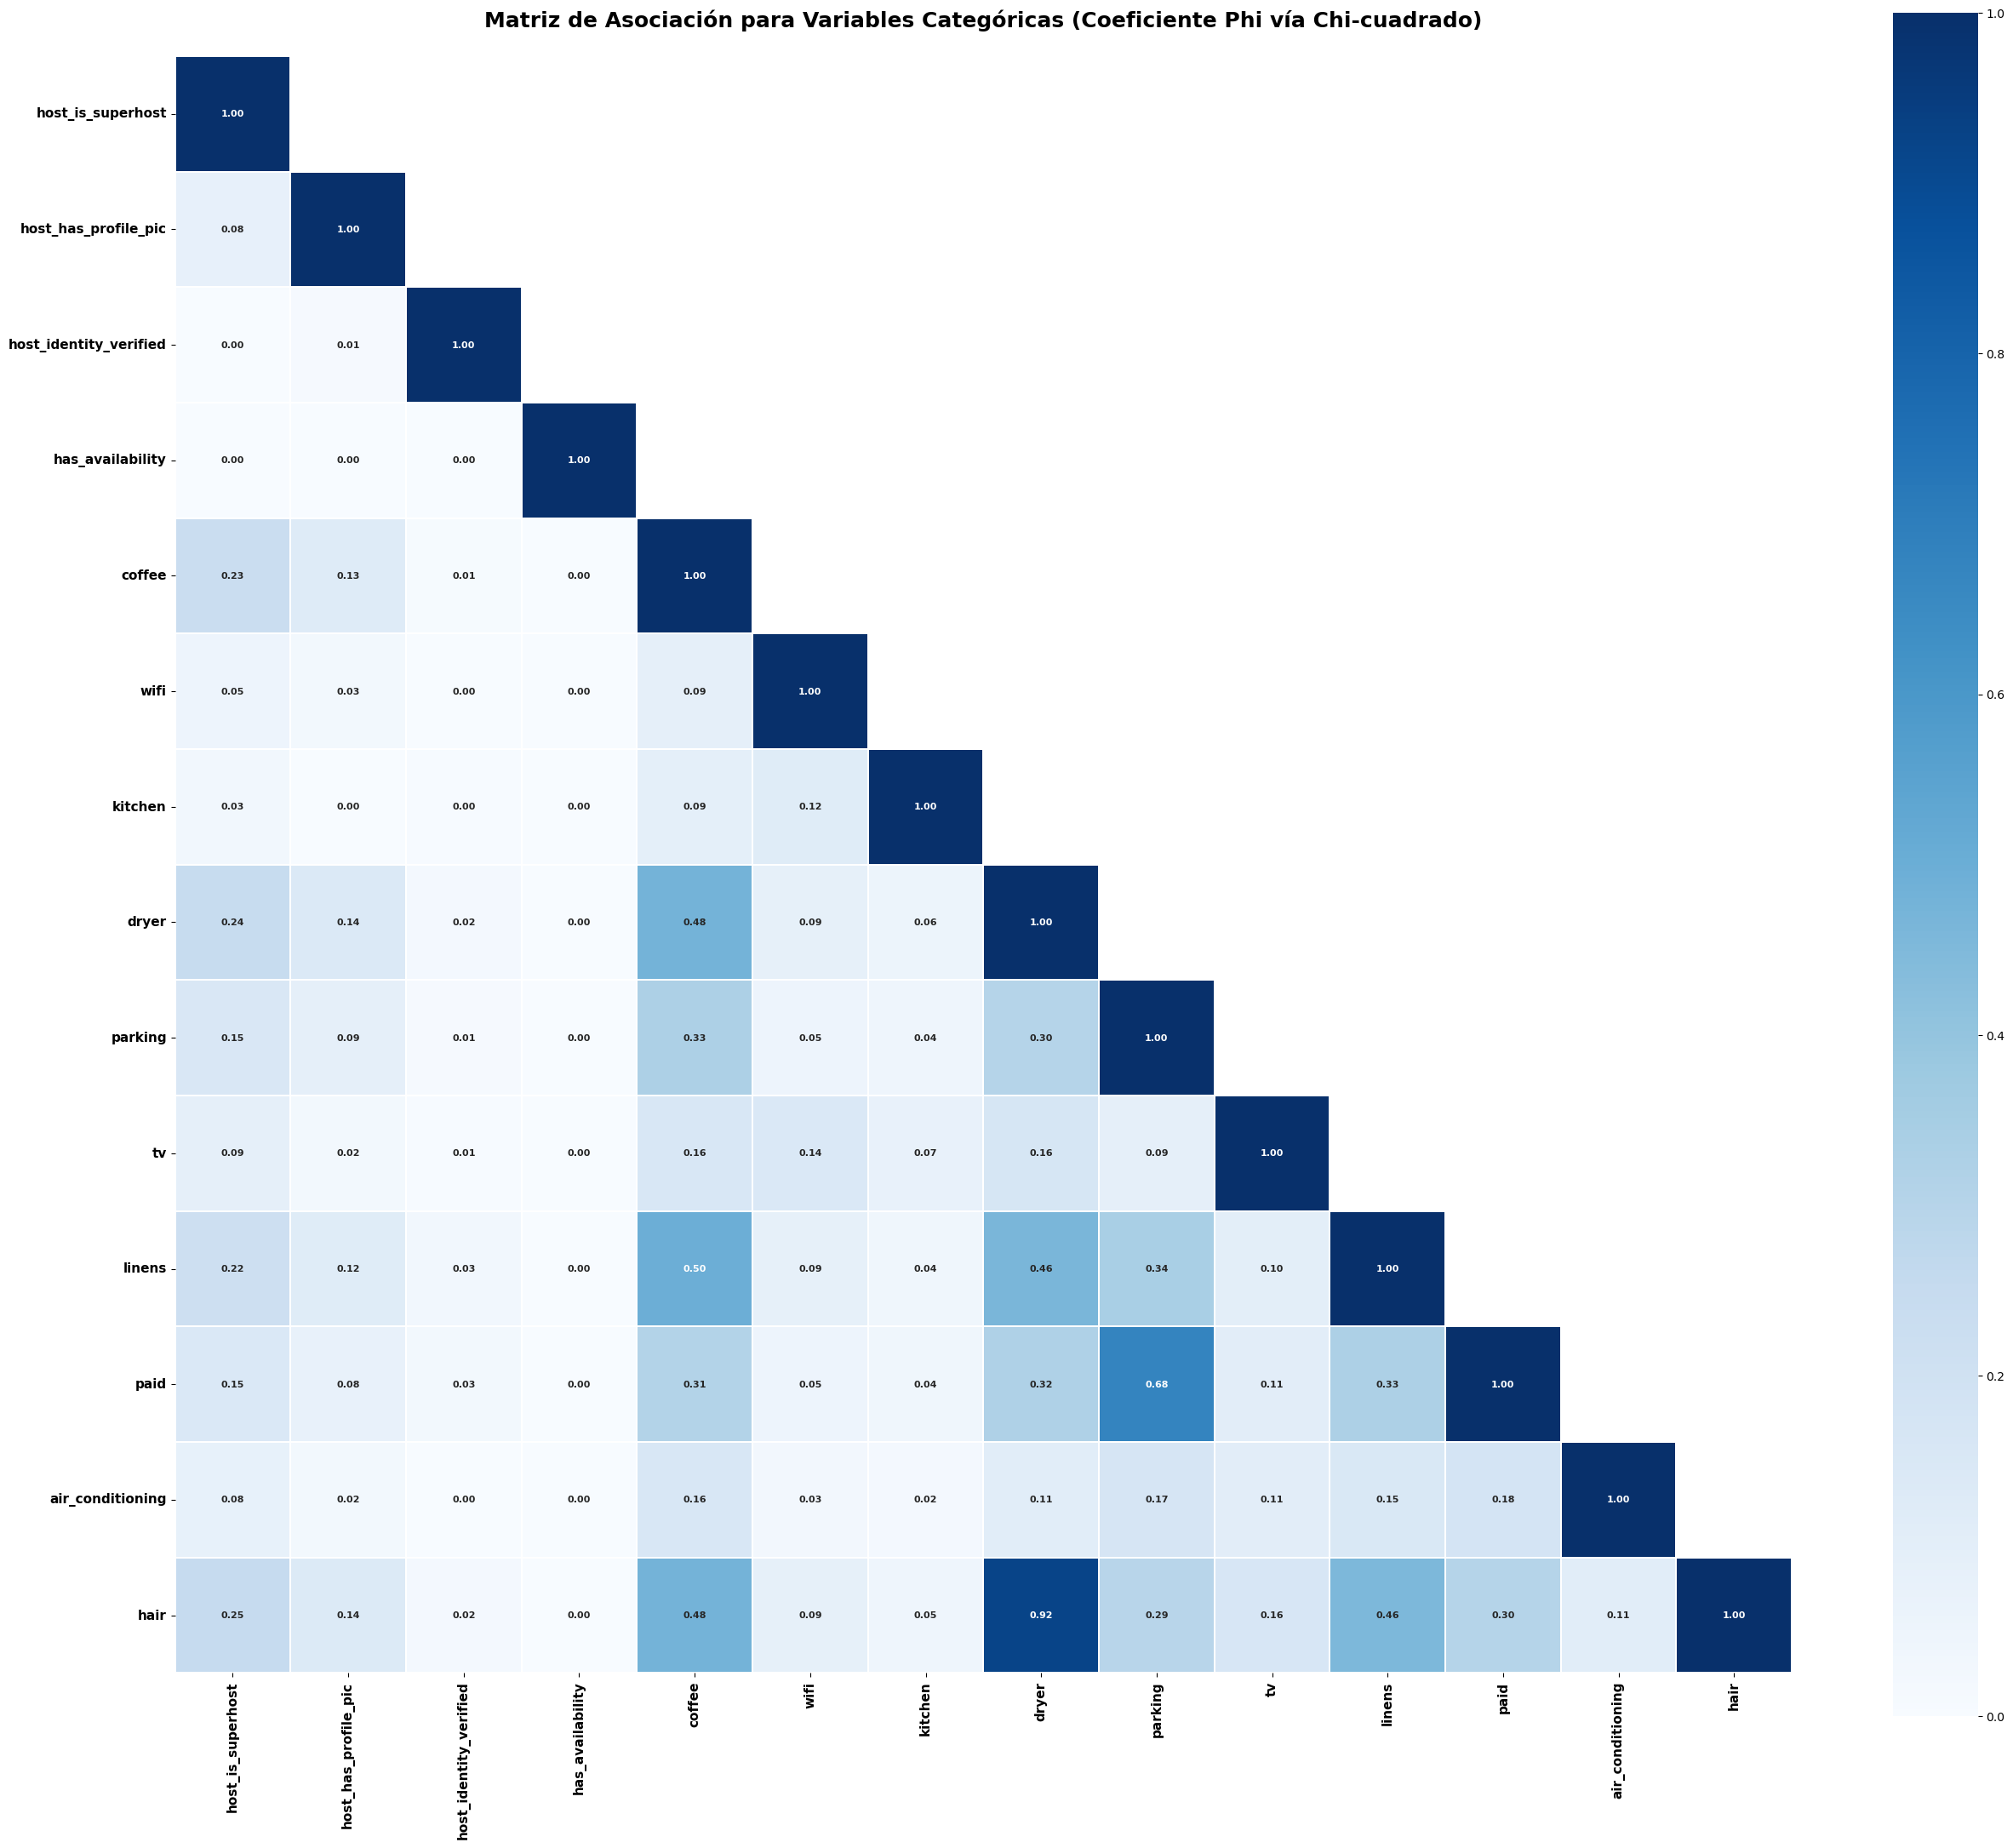

In [605]:
display(
    HTML(
        "<div style='max-height: 650px; max-width: 100%; overflow: auto; border: 2px solid #ccc; border-radius: 4px;'>"
    )
)

# Creamos una lista con las variables booleanas (categoricas binarias)
variables_binarias = [
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 
    'has_availability', 'coffee', 'wifi', 'kitchen', 'dryer', 
    'parking', 'tv', 'linens', 'paid', 'air_conditioning', 'hair'
]

df_binarias = df_categoricas[variables_binarias]
n = len(variables_binarias)

# Creamos una matriz vaica para guardar la fuerza de asociación (Phi) de 0 a 1
matriz_phi = pd.DataFrame(np.zeros((n, n)), index=variables_binarias, columns=variables_binarias)

for i in range(n):
    for j in range(n):
        if i == j:
            matriz_phi.iloc[i, j] = 1.0  # Asociación perfecta consigo misma
        else:
            var1 = variables_binarias[i]
            var2 = variables_binarias[j]
            
            # Construimos la tabla de contingencia de frecuencias absolutas
            tabla = pd.crosstab(df_binarias[var1], df_binarias[var2])
            
            # Verificamos que la tabla sea una matriz válida de 2x2
            if not tabla.empty and tabla.size == 4:
                try:
                    # Calculamos el estadístico chi2
                    chi2, _, _, _ = chi2_contingency(tabla, correction=False)
                    total_muestras = tabla.sum().sum()
                    
                    # Convertimos el estadístico Chi2 al Coeficiente Phi (Escala 0 a 1)
                    phi = np.sqrt(chi2 / total_muestras)
                    matriz_phi.iloc[i, j] = phi
                except ValueError:
                    matriz_phi.iloc[i, j] = 0.0

# Definimos el tamaño del grafico
plt.figure(figsize=(26, 22))

# Ocultamos la mitad superior
mascara = np.triu(np.ones_like(matriz_phi, dtype=bool), k=1)

# Configuramos el heatmap
sns.heatmap(
    matriz_phi,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="Blues",              
    linewidths=0.3,
    annot_kws={"size": 8, "weight": "bold"},
    vmin=0,                  
    vmax=1,
    square=True
)

# Configuramos tipografías y títulos legibles tal como los tenías
plt.xticks(rotation=90, fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.title(
    "Matriz de Asociación para Variables Categóricas (Coeficiente Phi vía Chi-cuadrado)",
    fontsize=18,
    weight="bold",
    pad=25,
)
plt.tight_layout()

# Renderizar el gráfico dentro del contenedor y cerrar el bloque HTML
plt.show()
display(HTML("</div>"))

# Libera la memoria RAM inmediatamente para mantener la notebook optimizada
plt.close()

#### GRAFICAS VARIAS PARA VISUALIZAR PATRONES, COMPORTAMIENTOS

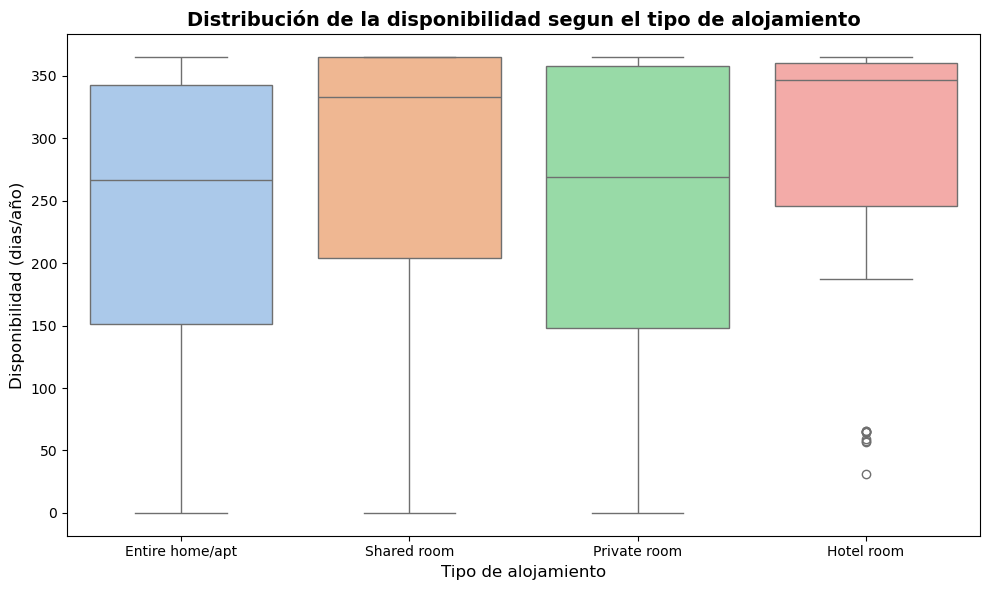

In [606]:
#Configuramos el tamaño
plt.figure(figsize=(10, 6))

# Creamos el boxplot multiple
sns.boxplot(
    x='room_type',              
    y='availability_365',       
    data=df_4,                    
    palette='pastel',           
    hue='room_type',            
    legend=False            
)

# Personalizamos títulos y etiquetas
plt.title('Distribución de la disponibilidad segun el tipo de alojamiento', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de alojamiento', fontsize=12)
plt.ylabel('Disponibilidad (dias/año)', fontsize=12)

# 4. Ajustamos el diseño y mostramos
plt.tight_layout()
plt.show()

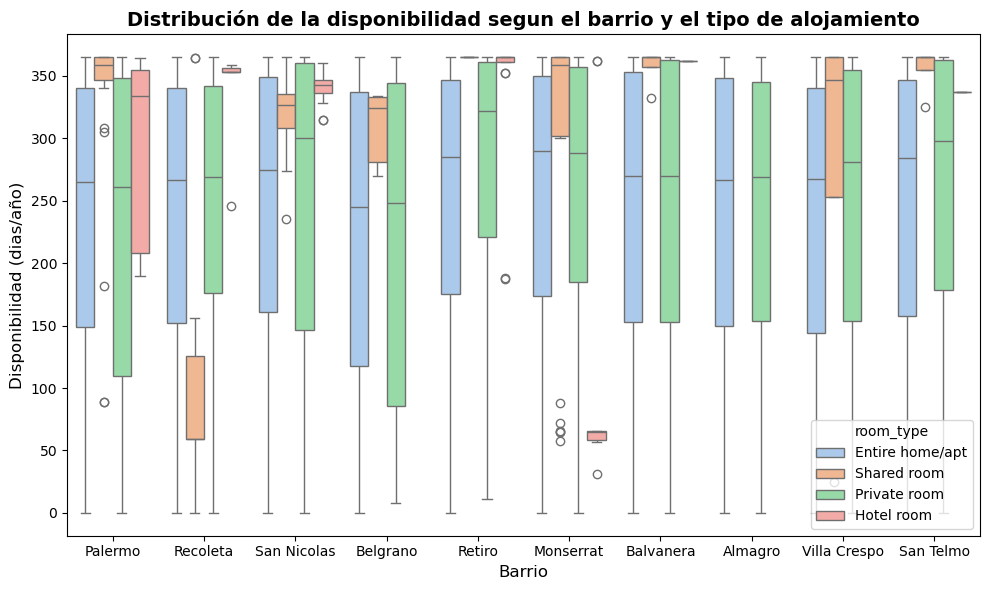

In [607]:
#Configuramos el tamaño
plt.figure(figsize=(10, 6))

#Filtramos el top 10 cde barrios con mas cantidad de anuncios
top_10_barrios = df_4['neighbourhood_cleansed'].value_counts().iloc[:10].index

# Creamos el boxplot multiple
sns.boxplot(
    x='neighbourhood_cleansed',              
    y='availability_365',       
    data=df_4[df_4['neighbourhood_cleansed'].isin(top_10_barrios)],    
    order=top_10_barrios,
    palette='pastel',           
    hue='room_type',            
    legend=True            
)

# Personalizamos títulos y etiquetas
plt.title('Distribución de la disponibilidad segun el barrio y el tipo de alojamiento', fontsize=14, fontweight='bold')
plt.xlabel('Barrio', fontsize=12)
plt.ylabel('Disponibilidad (dias/año)', fontsize=12)

# 4. Ajustamos el diseño y mostramos
plt.tight_layout()
plt.show()

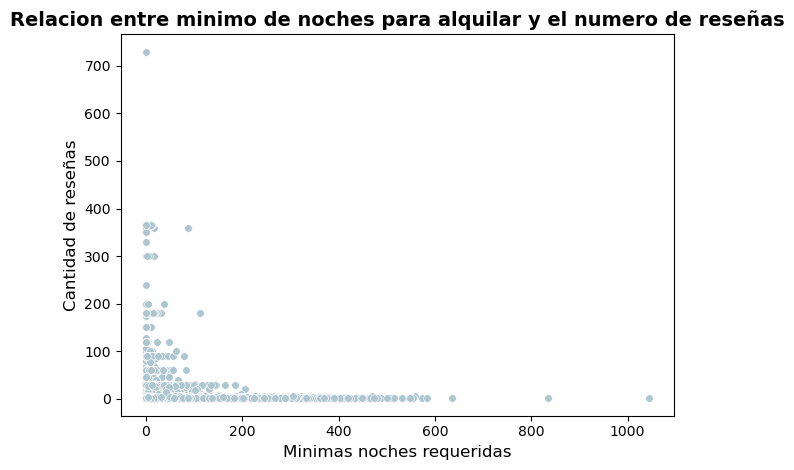

In [608]:
sns.scatterplot(
    x='number_of_reviews', 
    y='minimum_nights', 
    data=df_4,
    alpha=1,          
    color='#aec6cf',    
    s=30                
)
# Personalizamos títulos y ejes
plt.title('Relacion entre minimo de noches para alquilar y el numero de reseñas', fontsize=14, fontweight='bold')
plt.xlabel('Minimas noches requeridas', fontsize=12)
plt.ylabel('Cantidad de reseñas', fontsize=12)

# Ajustamos diseño y mostramos
plt.tight_layout()
plt.show()

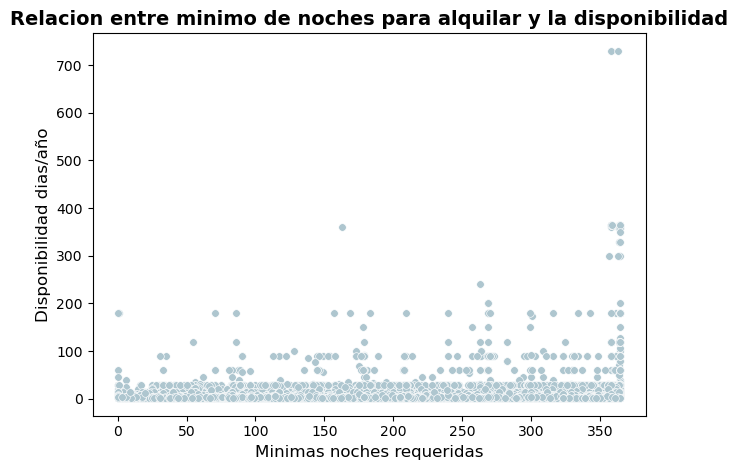

In [609]:
sns.scatterplot(
    x='availability_365', 
    y='minimum_nights', 
    data=df_4,
    alpha=1,          # Transparencia para ver la acumulación de puntos
    color='#aec6cf',    # Color azul pastel para mantener tu estética
    s=30                # Tamaño de los puntos
)

# Personalizamos títulos y ejes
plt.title('Relacion entre minimo de noches para alquilar y la disponibilidad', fontsize=14, fontweight='bold')
plt.xlabel('Minimas noches requeridas', fontsize=12)
plt.ylabel('Disponibilidad dias/año', fontsize=12)

# Ajustamos diseño y mostramos
plt.tight_layout()
plt.show()

Vamos a analizar que ocurre con la relacion entre los amenities y el puntaje de los alojamientos. Estamos buscando correlacion entre un features categoricas binaria y otras numericas por lo que vamos a utilizar **"correlacion punto-biserial"**

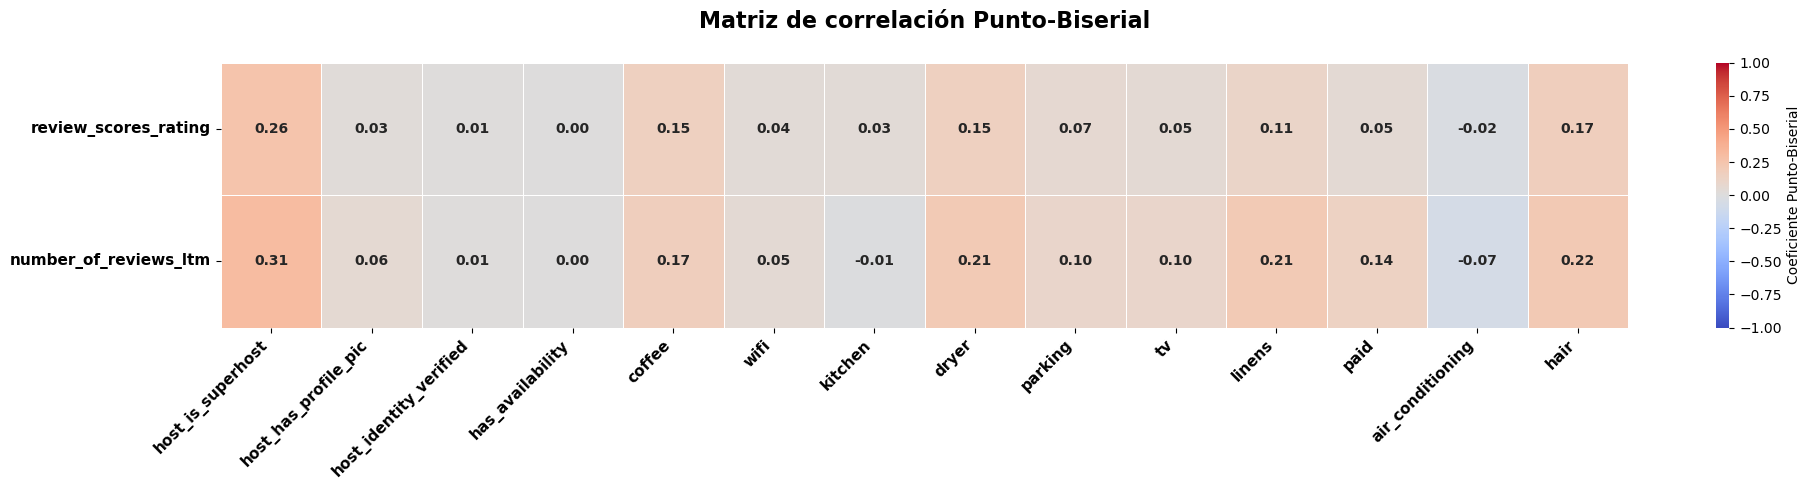

In [610]:
display(
    HTML(
        "<div style='max-height: 650px; max-width: 100%; overflow: auto; border: 2px solid #ccc; border-radius: 4px;'>"
    )
)

# Definicion de lista de variables a evaluar
variables_numericas = ['review_scores_rating', 'number_of_reviews_ltm']
variables_binarias = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability', 'coffee', 'wifi', 'kitchen', 'dryer', 
                      'parking', 'tv', 'linens', 'paid', 'air_conditioning', 'hair']

n_num = len(variables_numericas)
n_bin = len(variables_binarias)

# Definimos el tamaño de la matriz biserial
matriz_biserial = pd.DataFrame(
    np.zeros((n_num, n_bin)), 
    index=variables_numericas, 
    columns=variables_binarias
)

for num in variables_numericas:
    for binaria in variables_binarias:
        # Eliminamos nulos en la pareja actual para evitar fallos en el cálculo
        df_pareja = df_4[[num, binaria]].dropna()
        
        # Convertimos booleanos a 0 y 1 de forma segura
        serie_binaria_num = df_pareja[binaria].astype(int)
        serie_numerica = df_pareja[num]
        
        # Validamos que la variable binaria siga teniendo sus 2 clases tras remover nulos
        if len(serie_binaria_num.unique()) == 2:
            try:
                coeficiente, _ = pointbiserialr(serie_binaria_num, serie_numerica)
                matriz_biserial.loc[num, binaria] = coeficiente
            except ValueError:
                matriz_biserial.loc[num, binaria] = 0.0

# Definimos el tamaño del grafico
plt.figure(figsize=(20, 5))

# Configuramos el heatmap
sns.heatmap(
    matriz_biserial,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",        
    linewidths=0.5,
    annot_kws={"size": 10, "weight": "bold"},
    vmin=-1,                   
    vmax=1,
    cbar_kws={'label': 'Coeficiente Punto-Biserial'}
)

# Ajustamos el texto
plt.xticks(rotation=45, ha='right', fontsize=11, weight="bold")
plt.yticks(rotation=0, fontsize=11, weight="bold")
plt.title(
    "Matriz de correlación Punto-Biserial",
    fontsize=16,
    weight="bold",
    pad=25,
)
plt.tight_layout()
plt.show()
display(HTML("</div>"))

# Limpieza preventiva de memoria RAM
plt.close()

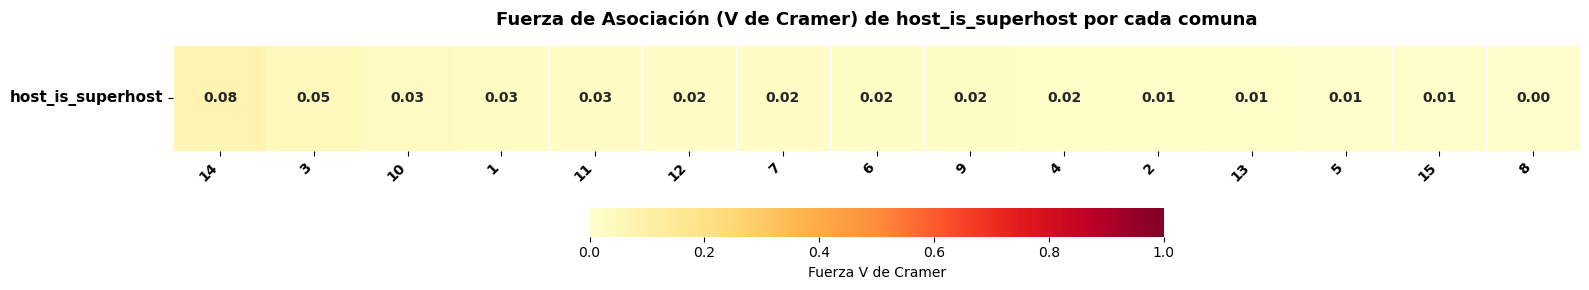

In [611]:
# 1. Definimos las dos variables a cruzar
var_binaria = 'host_is_superhost'
var_nominal = 'comuna'

# Obtenemos las categorias unicas de comunas
categorias_nominales = df_4[var_nominal].dropna().unique()

# Creamos un dataframe de 1 fila x 15 columnas para guardar los resultados
matriz_v_cramer = pd.DataFrame(
    np.zeros((1, len(categorias_nominales))),
    index=[var_binaria],
    columns=categorias_nominales
)

# Calculamos la V de Cramer aislando cada categoría contra la binaria
for cat in categorias_nominales:
    # Creamos una columna temporal que marca si pertenece a esa categoría específica (True/False)
    df_temporal = df_4[[var_binaria, var_nominal]].dropna()
    col_auxiliar = df_temporal[var_nominal] == cat
    
    # Armamos la matriz de contingencia 2x2 para esa categoría
    tabla_2x2 = pd.crosstab(df_temporal[var_binaria], col_auxiliar)
    
    if tabla_2x2.size == 4:
        try:
            chi2, _, _, _ = chi2_contingency(tabla_2x2, correction=False)
            total = tabla_2x2.sum().sum()
            
            # Fórmula V de Cramer para tabla 2x2 (min_dimensión siempre es 1)
            v_cramer = np.sqrt(chi2 / total)
            matriz_v_cramer.loc[var_binaria, cat] = v_cramer
        except ValueError:
            matriz_v_cramer.loc[var_binaria, cat] = 0.0

# Acomodamos las 15 columnas de mayor a menor fuerza para facilitar el EDA
matriz_v_cramer = matriz_v_cramer.reindex(columns=matriz_v_cramer.iloc[0].sort_values(ascending=False).index)

# Definimos el tamaño del grafico
plt.figure(figsize=(16, 3))

#Definimos configuraciones del heatmap
sns.heatmap(
    matriz_v_cramer,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",             
    linewidths=0.5,
    annot_kws={"size": 10, "weight": "bold"},
    vmin=0, vmax=1,        
    cbar_kws={'label': 'Fuerza V de Cramer', 'orientation': 'horizontal', 'pad': 0.3}
)

plt.xticks(rotation=45, ha='right', fontsize=10, weight="bold")
plt.yticks(rotation=0, fontsize=11, weight="bold")
plt.title(f"Fuerza de Asociación (V de Cramer) de {var_binaria} por cada {var_nominal}", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## RESUMEN EDA 
Luego de haber evaluado con mayor profundidad el dataset, eliminamos 15 features totalmente vacias, las cuales no aportaban en ningun aspecto. Luego se realizo la conversión de algunas variables que tenían formato incorrecto (hicimos coincidir en lógica su tipo de variable estadística). Tambien se regularizo el tipo de variable categorica binaria, solamente pudiendo tomar 3 valores, True, False y NaN, sin otro posible valor.

Se extrajo de ciertas columnas datos que no estaban totalmente explicitos como era las amenities para poder procesarlos, y luego evaluar si tenian algun tipo de correlacion e incidencia sobre alguna variable puntual.

Se agruparon 4 variables (años y meses desde que la persona es host o user) directamente en meses, ya que estaban divididas en 4 columnas representando lo mismo, sin sentido. Las unimos en meses y quedaron resumidas en 2 columnas sin perder informacion.

Luego de este tratamiento pasamos a tener 39 variables numericas y 39 variables categoricas.

Procedimos a realizar distintas metricas evaluando primero metricas descriptivas para las variables numericas analizando su media, mediana, moda, skewness,  curtosis, cuartiles, varianza, desviacion estandar, etc. Tambien obtuvimos matrices de correlacion con metodo como pearson, kendall y spearrman. De estas ultimas matrices se pudo observar 



# NL hasta aca hice

<!-- Entonces eliminamos la variable property_type -->

**Ya tenemos el dataset con los atributos relevantes y el target listo para su procesamiento y limpieza**

Primero estudiamos la distribucion del target

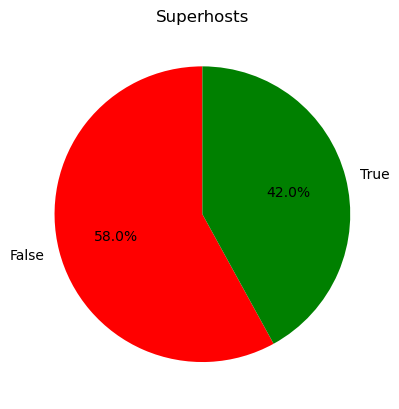

In [612]:
counts = df_4["host_is_superhost"].value_counts()

color_map = {
    1: "green",
    0: "red"
}

colors = [color_map[v] for v in counts.index]

counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Superhosts")
plt.ylabel("")
plt.show()

Venos que es un problema de clasificacion balanceado

In [613]:
df_4.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,wifi,kitchen,dryer,parking,tv,linens,paid,air_conditioning,hair,comuna
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,...,True,True,False,False,True,False,False,True,False,1
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,...,True,False,False,True,False,False,True,True,False,1
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,...,True,True,False,False,True,False,False,True,False,3
3,1004530078359434134,https://www.airbnb.com/rooms/1004530078359434134,20260125052844,2026-01-25,city scrape,Departamento en Recoleta,Relax with the whole family at this peaceful p...,https://a0.muscache.com/pictures/0beb83d5-381d...,1409800,https://www.airbnb.com/users/show/1409800,...,True,True,True,False,False,True,False,True,True,3
4,800145927121871422,https://www.airbnb.com/rooms/800145927121871422,20260125052844,2026-01-25,city scrape,Coqueto para 4 personas,3 rooms: master bedroom with king size bed and...,https://a0.muscache.com/pictures/d2a502bc-2ac0...,467965425,https://www.airbnb.com/users/show/467965425,...,True,True,False,True,True,False,False,True,False,5


In [614]:
df_4.shape

(27348, 78)

#### Vamos a realizar el train_test_split

In [615]:
y = df_4['host_is_superhost']
X = df_4.drop(columns=['host_is_superhost']).copy()

Verificamos filas y columnas de X e y

In [616]:
X.shape, y.shape

((27348, 77), (27348,))

ahora vamos a realizar el train test split asi podemos realizar todas las traformaciones en el train y luego la aplicamos en el test

In [617]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y )

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (19143, 77)
X_test:  (8205, 77)
y_train: (19143,)
y_test:  (8205,)


## Reduccion de dimensionalidad

Ya quitamos algunas variables redundantes y sin datos y creamos otras que son utiles para el problema de ML (cambiar el atributo origical de bariro como string a variables binarias)

## Seleccion de atributos

Primero buscamos filtrar atributos redundantes (muy correlcionados entre si) o que puedan causar problemas de multicolinealidad

Ralizamos una matriz de correlacion entre las variables numericas para capturar posibles problemas de multicolinealidad en atributos. Suponemos que correlacion de Spearman (monotonica) mayor a 0.8 es indicativo de atributos redundantes

* Por otro lado prestamos atencion a la relacion entre los distintos puntajes de reviews entre ellos y la experiencia del host para darnos una idea de atributos de un host exitoso

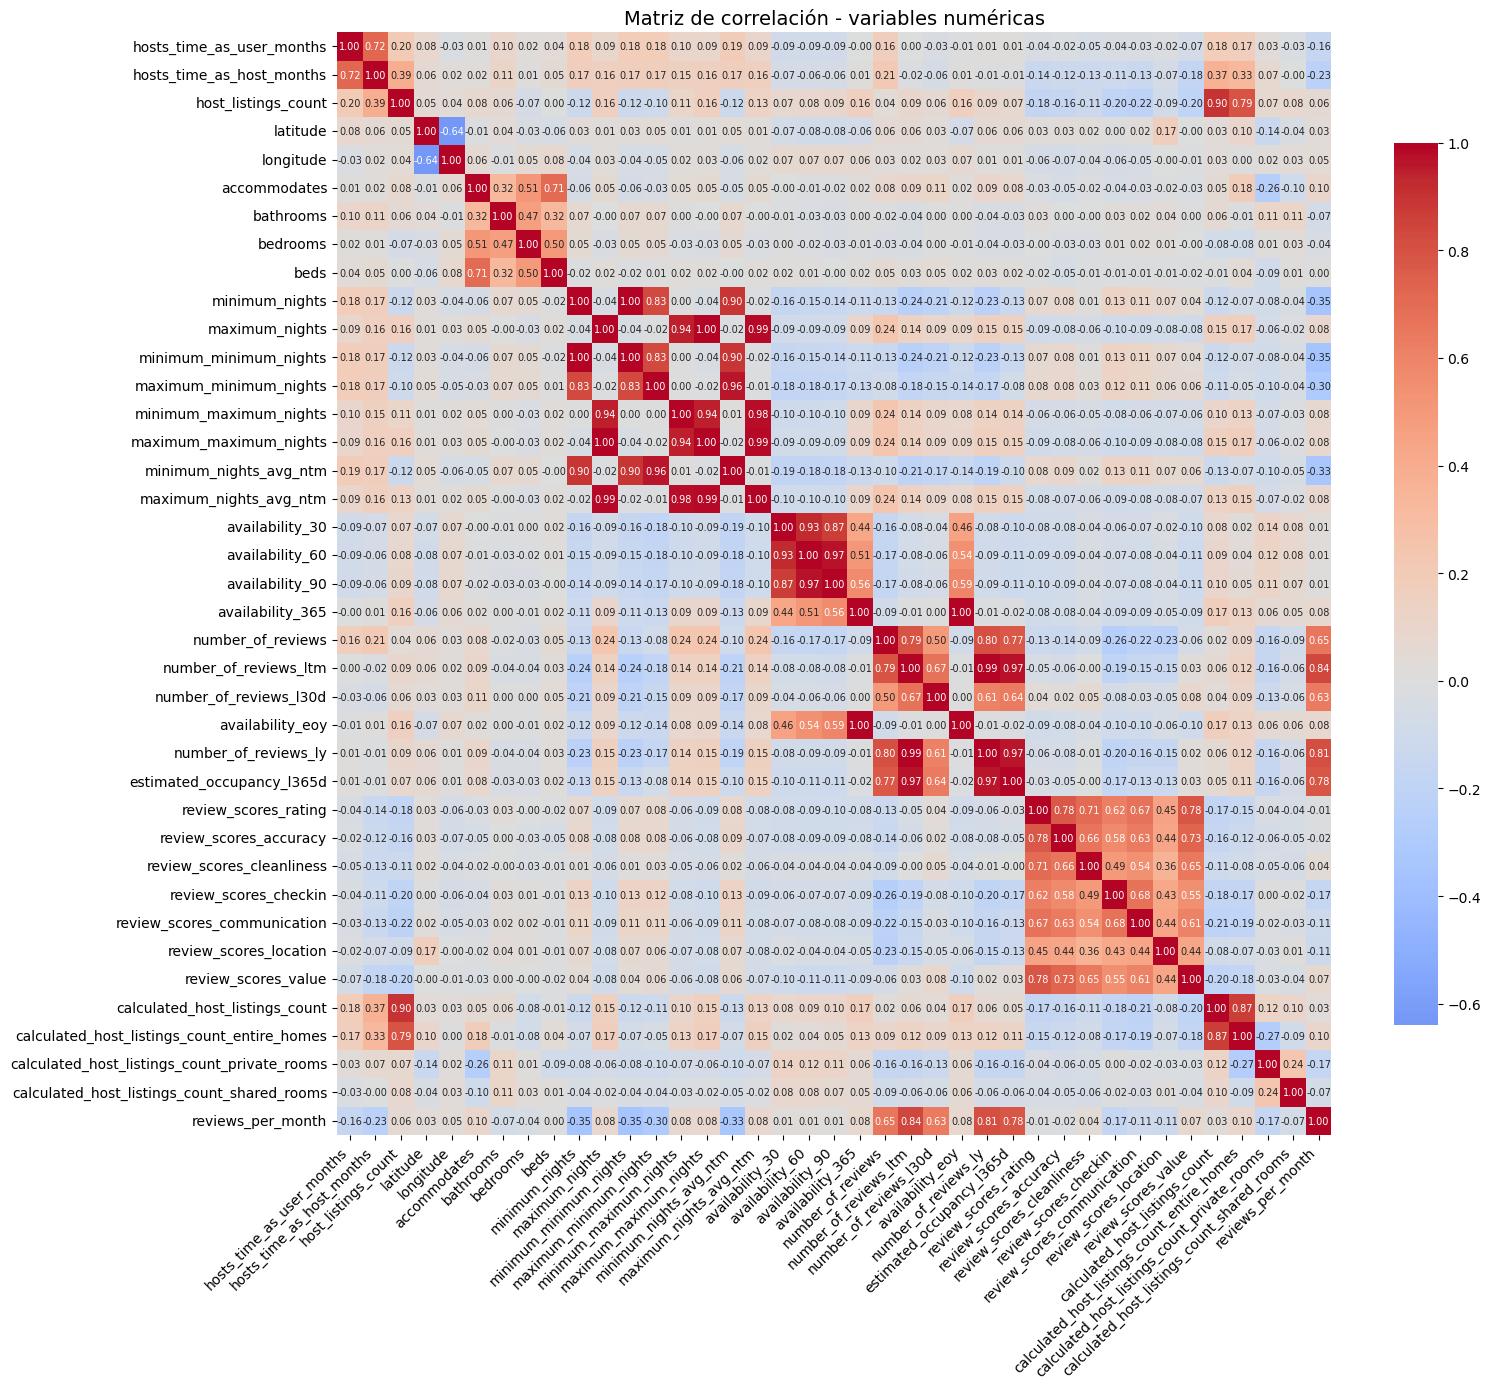

In [618]:
# Seleccionar solo las columnas numéricas de la lista
numerical_cols = X_train.select_dtypes(include=['number']).columns

# Calcular matriz de correlación Spearman
corr = X_train[numerical_cols].corr(method='spearman')

# Graficar
plt.figure(figsize=(16, 14))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación - variables numéricas", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Interesante que la experiencia del host como host y como usuario no esta para nada correlacionada con los puntajes de los reviews. Esto es una buena noticia porque como inversores solo podemos elegir en que invertir, pero no podemos comprar tiempo de experiencia
Resulta interesante tambien hecho de que la correlacion mas fuerte de ratings (el puntaje mas importante) es con 'accuracy' y 'value'. Esto se puede interpretar como que los usuarion valoran mucho la exactitud de la descripcion del listing y la relacion calidad-precio (value for money)

**Reducción de dimensionalidad por correlación entre variables numéricas**

A partir de la matriz de correlación de Spearman, identificamos tres grupos de 
variables altamente correlacionadas entre sí, lo que indica redundancia de información:

**Grupo 1 - Review scores**: `review_scores_rating`, `accuracy`, `cleanliness`, 
`checkin`, `communication` y `value` presentan correlaciones superiores a 0.55 entre sí. 
Conservamos `review_scores_rating` como representante del grupo (es la variable con 
correlaciones más altas y consistentes con el resto) y `review_scores_location`, 
que mantiene correlaciones bajas (~0.44) y por lo tanto aporta información distinta.

**Grupo 2 - Availability**: `availability_30`, `availability_90`, `availability_365` 
y `availability_eoy` presentan correlación moderada-alta con `availability_60` 
(mínimo 0.52). Conservamos únicamente `availability_60` como representante del grupo.

**Grupo 3 - Reviews/Occupancy**: `number_of_reviews`, `number_of_reviews_l30d`, 
`number_of_reviews_ly` y `estimated_occupancy_l365d` presentan correlación de al 
menos 0.66 con `number_of_reviews_ltm`. Conservamos `number_of_reviews_ltm` como 
representante del grupo.

Con esta reducción pasamos de 13 variables potencialmente redundantes a 4, 
disminuyendo la dimensionalidad sin perder información relevante para el análisis.

## Yo aca quitaria id y host_id porque solo agregan ruido

In [619]:
columnas_eliminar = [
    # Grupo 1 - Review scores
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_value',
    
    # Grupo 2 - Availability
    'availability_30',
    'availability_90',
    'availability_365',
    'availability_eoy',
    
    # Grupo 3 - Reviews/Occupancy
    'number_of_reviews',
    'number_of_reviews_l30d',
    'number_of_reviews_ly',
    'estimated_occupancy_l365d',
]

X_train = X_train.drop(columns=columnas_eliminar).copy()
X_test = X_test.drop(columns=columnas_eliminar).copy()
print(X_train.shape)
print(X_train.columns.tolist())

(19143, 64)
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'hosts_time_as_user_months', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_picture_url', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_60', 'calendar_last_scraped', 'number_of_reviews_ltm', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_location', 'license', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_coun

In [620]:
X_train.describe()

,last_scraped,hosts_time_as_user_months,hosts_time_as_host_months,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,number_of_reviews_ltm,first_review,last_review,review_scores_rating,review_scores_location,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,19143,19143.0,19143.0,19143.0,19143.0,19143.0,19143.0,19137.0,19106.0,19136.0,...,19143.0,16850,16850,16850.0,16850.0,19143.0,19143.0,19143.0,19143.0,16850.0
mean,2026-01-25 11:35:26.375176,92.318393,66.802696,18.011597,-34.592027,-58.416347,2.945359,1.227779,1.163142,1.898411,...,12.273259,2022-12-27 01:41:57.222552,2025-08-01 21:24:53.412463,4.7765,4.870493,12.385572,11.771352,0.491772,0.047955,1.465412
min,2026-01-25 00:00:00,0.0,0.0,1.0,-34.66774,-58.52792,1.0,0.0,0.0,0.0,...,0.0,2010-05-19 00:00:00,2013-01-06 00:00:00,1.0,1.0,1.0,0.0,0.0,0.0,0.01
25%,2026-01-25 00:00:00,45.0,28.0,1.0,-34.60315,-58.435961,2.0,1.0,1.0,1.0,...,1.0,2022-05-31 00:00:00,2025-10-07 00:00:00,4.73,4.85,1.0,1.0,0.0,0.0,0.38
50%,2026-01-25 00:00:00,99.0,49.0,3.0,-34.59135,-58.41841,2.0,1.0,1.0,1.0,...,5.0,2023-10-28 12:00:00,2025-12-20 00:00:00,4.87,4.94,2.0,2.0,0.0,0.0,1.0
75%,2026-01-26 00:00:00,128.0,100.0,16.0,-34.581496,-58.391128,4.0,1.0,1.0,2.0,...,17.0,2024-12-03 00:00:00,2026-01-08 00:00:00,4.97,5.0,9.0,8.0,0.0,0.0,2.04
max,2026-01-26 00:00:00,201.0,180.0,945.0,-34.53621,-58.355403,16.0,20.0,19.0,36.0,...,251.0,2026-01-24 00:00:00,2026-01-25 00:00:00,5.0,5.0,188.0,188.0,35.0,17.0,27.17
std,NaN,47.830703,47.564844,39.81634,0.017876,0.029894,1.548722,0.666852,0.91332,1.507104,...,17.424874,NaN,NaN,0.362541,0.254276,28.017172,27.998599,2.321672,0.639894,1.556295


Vamos a analizar la relacon entre las varibles 'room_type' y 'property_type'.  Como vemos room_type es una agrupamiento de las caracteristicas de property_type. Por lo tanto vamos a eliminar la columna property_type

In [621]:
X_train[['room_type', 'property_type']].value_counts()

room_type        property_type                     
Entire home/apt  Entire rental unit                    13885
                 Entire condo                           1987
Private room     Private room in rental unit             584
Entire home/apt  Entire serviced apartment               583
Private room     Private room in home                    445
Entire home/apt  Entire loft                             422
                 Entire home                             291
Private room     Private room in condo                   114
Entire home/apt  Entire vacation home                    112
Private room     Room in hotel                           106
                 Private room in guesthouse               76
                 Private room in casa particular          65
                 Private room in bed and breakfast        48
                 Private room in serviced apartment       42
Entire home/apt  Entire townhouse                         31
Private room     Private room in 

Hacemos una verifiacion por CremmerV  para ver si mantiene realcion con el target

In [622]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

v_room = cramers_v(X_train['room_type'], y_train)
print(f"Cramér's V room_type vs target: {v_room:.4f}")

Cramér's V room_type vs target: 0.1006


Entonces eliminamos la variable property_type

In [623]:
X_train = X_train.drop(columns=['property_type']).copy()
X_test = X_test.drop(columns=['property_type']).copy()

#### Ahora vamos a trabajar con  de las variables categoricas

In [624]:
X_train.describe(include='str')

,id,listing_url,scrape_id,source,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_location,host_about,host_picture_url,neighbourhood_cleansed,room_type,bathrooms_text,license,comuna
count,19143,19143,19143,19143,19143,18704,19142,19143,19143,19143,19143,19143,15067,10901,19143,19143,19143,19136,315,19143
unique,19143,19143,1,1,18278,16801,18867,10895,10895,10419,10446,3218,525,4738,9918,45,4,41,287,15
top,1095394486331042000,https://www.airbnb.com/rooms/1095394486331042000,20260125052844,city scrape,Departamento en Buenos Aires,Keep it simple at this peaceful and centrally-...,https://a0.muscache.com/pictures/hosting/Hosti...,3469227,https://www.airbnb.com/users/show/3469227,1462630274377502765,https://www.airbnb.com/users/profile/146263027...,Federico,"Buenos Aires, Argentina","Soy de Buenos Aires, capital federal",https://a0.muscache.com/im/users/3469227/profi...,Palermo,Entire home/apt,1 bath,IF-2025-23263934-GCABA-DGDTU,14
freq,1,1,19143,19143,45,102,7,140,140,140,140,330,12221,140,140,6270,17408,13792,7,6270


Vamos a analizar la variable 'has_availavility' 

In [625]:
X_train['has_availability'].value_counts()

has_availability
True    19011
Name: count, dtype: Int64

'has_avalibility' es una variable constnate todo los valores son True por lo tanto no aporta valor y la vamos a eliminar

In [626]:
X_train=X_train.drop(columns=['has_availability']).copy()
X_test=X_test.drop(columns=['has_availability']).copy()

Luego seguimos con host_identitiy_verified                      

In [627]:
X_train['host_identity_verified'].value_counts()

host_identity_verified
True     19029
False      114
Name: count, dtype: Int64

Tiene varios valores esta variable y parece bastante util, ya que tener la identidad verificada deberia generar confianza en los huespedes.
Entonces vamos a hacer 't'=1 y 'f'= 0

In [628]:
X_train['host_identity_verified'] = X_train['host_identity_verified'].map({'t': 1, 'f': 0})
X_test['host_identity_verified'] = X_test['host_identity_verified'].map({'t': 1, 'f': 0})

Ahora avanzamos con la variable 'neighbourhood_cleansed'. vemos que esta variable cuenta con 48 datos distintos, lo que vamos hacer es agruparlos por columnas por lo que nos deberia quedar de solo 14 variables y ahi podemos hacer un OHE

Importo un csv con las comunas

In [629]:
comunas = pd.read_csv(r'barrios_comunas_caba.csv')

In [630]:
comunas.head()

,barrio,comuna
0,Palermo,14
1,Villa Devoto,11
2,Recoleta,2
3,Monserrat,1
4,San Nicolas,1


Verificamos que los barrios coincidan

Observamos que la variable'neighbourhood_cleansed' tiene alta cardinalidad, entonces para poder codificarla le reducimos la cardinalidad llevandola a la variable comuna que agrupa los barios y solo nos quedan 14 alternativas.

In [631]:
X_train[['neighbourhood_cleansed','comuna']].value_counts()

neighbourhood_cleansed  comuna
Palermo                 14        6270
Recoleta                2         2667
San Nicolas             1         1497
Belgrano                13         930
Retiro                  1          912
Monserrat               1          899
Balvanera               3          736
Almagro                 5          715
Villa Crespo            15         637
San Telmo               1          542
Colegiales              13         439
Chacarita               15         348
Nuñez                   13         331
Caballito               6          319
Constitucion            1          254
Puerto Madero           1          240
Villa Urquiza           12         213
Barracas                4          151
Saavedra                12         123
San Cristobal           3          106
Flores                  7           98
Boca                    4           69
Villa Del Parque        11          65
Boedo                   5           62
Coghlan                 12       

Primero eliminamos la variables 'neighbourhood_cleansed'

In [632]:
X_train = X_train.drop(columns=['neighbourhood_cleansed']).copy()
X_test = X_test.drop(columns=['neighbourhood_cleansed']).copy()

Verificamos que nos queda la variable comuna con 15 variables

In [633]:
X_train.comuna.unique()

<StringArray>
['13', '1', '14', '2', '5', '15', '10', '7', '3', '11', '12', '6', '4', '9',
 '8']
Length: 15, dtype: string

In [634]:
X_train['room_type'].unique()

<StringArray>
['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
Length: 4, dtype: string

Vamos  realizar el OHE a la variable 'comuna' y a la variable 'roon_type' ya que vemos que cuenta con solo 4 variables

In [635]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit en train, transform en train y test
columnas_ohe = ['comuna', 'room_type']

ohe_train = ohe.fit_transform(X_train[columnas_ohe])
ohe_test = ohe.transform(X_test[columnas_ohe])

# Crear dataframes con las nuevas columnas
ohe_cols = ohe.get_feature_names_out(columnas_ohe)

ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test.index)

# Eliminar columnas originales y agregar las codificadas
X_train = X_train.drop(columns=columnas_ohe)
X_train = pd.concat([X_train, ohe_train_df], axis=1)

X_test = X_test.drop(columns=columnas_ohe)
X_test = pd.concat([X_test, ohe_test_df], axis=1)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (19143, 76)
X_test: (8205, 76)


In [636]:
X_train.describe(include='str')

,id,listing_url,scrape_id,source,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_location,host_about,host_picture_url,bathrooms_text,license
count,19143,19143,19143,19143,19143,18704,19142,19143,19143,19143,19143,19143,15067,10901,19143,19136,315
unique,19143,19143,1,1,18278,16801,18867,10895,10895,10419,10446,3218,525,4738,9918,41,287
top,1095394486331042000,https://www.airbnb.com/rooms/1095394486331042000,20260125052844,city scrape,Departamento en Buenos Aires,Keep it simple at this peaceful and centrally-...,https://a0.muscache.com/pictures/hosting/Hosti...,3469227,https://www.airbnb.com/users/show/3469227,1462630274377502765,https://www.airbnb.com/users/profile/146263027...,Federico,"Buenos Aires, Argentina","Soy de Buenos Aires, capital federal",https://a0.muscache.com/im/users/3469227/profi...,1 bath,IF-2025-23263934-GCABA-DGDTU
freq,1,1,19143,19143,45,102,7,140,140,140,140,330,12221,140,140,13792,7


Todas estas variables por falta de valor cuantitativo para el target las vamos a eliminar:
listing_url, URL del alojamiento en Airbnb, es un link
scrape_id, ID del proceso de scraping
source, Fuente del scraping
name,  Nombre/título del alojamiento
host_url, URL del perfil del anfitrión
host_profile_id, ID del perfil del anfitrión

In [637]:
columnas_eliminar = ['listing_url', 'scrape_id', 'source', 'name', 
                    'host_id', 'host_url', 'host_profile_id']

X_train = X_train.drop(columns=[c for c in columnas_eliminar if c in X_train.columns]).copy()
X_test = X_test.drop(columns=[c for c in columnas_eliminar if c in X_test.columns]).copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (19143, 69)
X_test shape: (8205, 69)


#### Vamos a verificar los valor nulos que existan

In [638]:
X_train.isnull().sum().sort_values(ascending=False)

host_identity_verified    19143
license                   18828
host_about                 8242
host_location              4076
last_review                2293
                          ...  
comuna_8                      0
comuna_9                      0
room_type_Hotel room          0
room_type_Private room        0
room_type_Shared room         0
Length: 69, dtype: int64

In [639]:
X_train.isnull().sum()[X_train.isnull().sum() > 0].sort_values(ascending=False)

host_identity_verified    19143
license                   18828
host_about                 8242
host_location              4076
first_review               2293
last_review                2293
review_scores_location     2293
reviews_per_month          2293
review_scores_rating       2293
description                 439
minimum_nights               75
maximum_minimum_nights       75
minimum_minimum_nights       75
minimum_maximum_nights       75
maximum_nights               75
maximum_maximum_nights       75
bedrooms                     37
beds                          7
bathrooms_text                7
bathrooms                     6
picture_url                   1
dtype: int64

Hay varias columnas con valores booleanos asi que los vamos valores numericos 0/1

In [640]:
cols_bool = ['hair', 'dryer', 'coffee', 'linens', 'parking', 'paid', 
             'tv', 'air_conditioning', 'host_has_profile_pic', 'wifi', 'kitchen']

# Convertir en X_train y X_test
for col in cols_bool:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(int)
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(int)



Vamos a empezar a elimnar valores que no tienen nigun tipo de valor para nuestro target:
host_identity_verified, esta casi vacia la columna por lo tanto no aporta valor
License, Número de habilitación del alojamientoNula — en tu dataset estaba 98% vacía
host_location,  Ciudad/país que pone el host en su perfil
host_about, Descripción libre que escribe el host sobre sí mismo
description, Descripción libre del alojamientoMuy baja — texto no estructurado
bathrooms_text, Texto descriptivo de baños (ej: "1 bath", "shared bath"), y esta la variable numerica bathrooms
picture_urlURL de la foto del alojamiento
#### Como primer medida vamos a dropear todos estas columnas ####


In [641]:
columnas_eliminar = ['host_about', 'host_location', 'license', 'description', 'bathrooms_text', 'picture_url','host_identity_verified']

# Eliminar solo las que existen en cada dataframe
cols_train = [c for c in columnas_eliminar if c in X_train.columns]
cols_test = [c for c in columnas_eliminar if c in X_test.columns]

X_train = X_train.drop(columns=cols_train).copy()
X_test = X_test.drop(columns=cols_test).copy()

print(f"Columnas eliminadas en X_train: {cols_train}")
print(f"Columnas eliminadas en X_test: {cols_test}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Columnas eliminadas en X_train: ['host_about', 'host_location', 'license', 'description', 'bathrooms_text', 'picture_url', 'host_identity_verified']
Columnas eliminadas en X_test: ['host_about', 'host_location', 'license', 'description', 'bathrooms_text', 'picture_url', 'host_identity_verified']
X_train shape: (19143, 62)
X_test shape: (8205, 62)


Volvemos a ver cuales son los valores ausentes

In [642]:
X_train.isnull().sum()[X_train.isnull().sum() > 0].sort_values(ascending=False)

review_scores_location    2293
reviews_per_month         2293
last_review               2293
review_scores_rating      2293
first_review              2293
maximum_nights              75
minimum_nights              75
maximum_maximum_nights      75
maximum_minimum_nights      75
minimum_minimum_nights      75
minimum_maximum_nights      75
bedrooms                    37
beds                         7
bathrooms                    6
dtype: int64

Vemos que los valores faltante de review_scores_location, reviews_per_month, last_review, first_review tienen la misma cantidad y vimos cuando hicimos los anlisis de variable es porque tienen o reviews.

Las variables last_review y first_review, las eliminamos porque no aportan informacion importante al target.

In [643]:
X_train = X_train.drop(columns=['last_review', 'first_review']).copy()
X_test = X_test.drop(columns=['last_review', 'first_review']).copy()

In [644]:
# Verificar que los nulos en review_scores coinciden con 0 reviews
print(X_train[X_train['review_scores_rating'].isnull()]['number_of_reviews_ltm'].describe())

# Ver cuántos tienen 0 reviews en total
print(f"\nTotal con number_of_reviews_ltm == 0: {(X_train['number_of_reviews_ltm'] == 0).sum()}")
print(f"Total con review_scores_rating nulo: {X_train['review_scores_rating'].isnull().sum()}")

count    2293.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: number_of_reviews_ltm, dtype: Float64

Total con number_of_reviews_ltm == 0: 4460
Total con review_scores_rating nulo: 2293


Es decir: 100% de los nulos en review_scores corresponden a alojamientos sin reseñas recientes, confirma que el faltante es MAR (Missing At Random, condicionado a otra variable observada: no tener reviews)

Vamos la distribucion de las variables

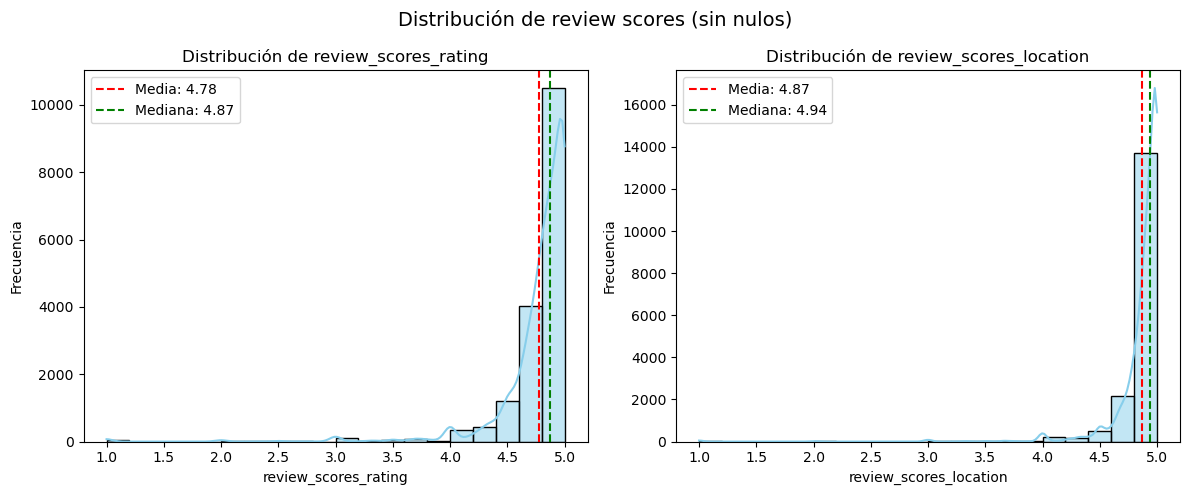

In [645]:
variables = ['review_scores_rating', 'review_scores_location']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(variables):
    sns.histplot(X_train[var].dropna(), bins=20, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    
    # Líneas de media y mediana
    media = X_train[var].mean()
    mediana = X_train[var].median()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
    axes[i].legend()

plt.suptitle('Distribución de review scores (sin nulos)', fontsize=14)
plt.tight_layout()
plt.show()

Ambas variables presentan asimetría negativa (cola hacia la izquierda). En distribuciones asimétricas, la media se ve afectada por los valores extremos, 
desplazándose hacia ellos. La mediana, al ser el valor central, representa mejor el comportamiento típico y es más robusta ante estos outliers. Por lo tanto, optamos por imputar con la mediana.

Vamos a analizar las variables 'minimum_nights', 'maximum_nights' que tienen la misma cantida de ausentes

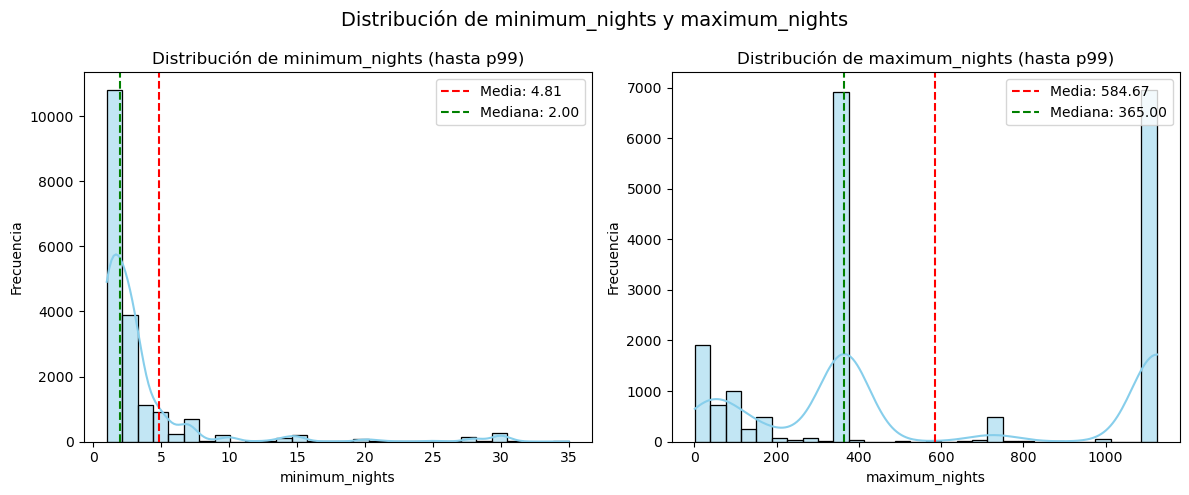

In [646]:
variables = ['minimum_nights', 'maximum_nights']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(variables):
    p99 = X_train[var].quantile(0.99)
    datos = X_train[X_train[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    
    media = X_train[var].mean()
    mediana = X_train[var].median()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
    axes[i].legend()

plt.suptitle('Distribución de minimum_nights y maximum_nights', fontsize=14)
plt.tight_layout()
plt.show()

Vemos comportamientos distintos de la distribucion. En 'minimum_nights' se ve una distribucion asimetrica con cola hacia la derecha entonces para imputar con el menor impacto en la distribucion lo hacemos con la mediana que vemos cae donde esta la mayor poblacion. 
En el caso del 'maximum_nights' es una distgribucion multimodal con varios picos, asi que si imputamos la mediana vemos que cae en el pico mas pronunciado que es 365 que debe ser el valor mas estandar que se pone por defecto.
Conclusion en ambos graficos hay que imputar con la mediana.

Ahora analicemos la ultima que nos falta que seria bedrooms

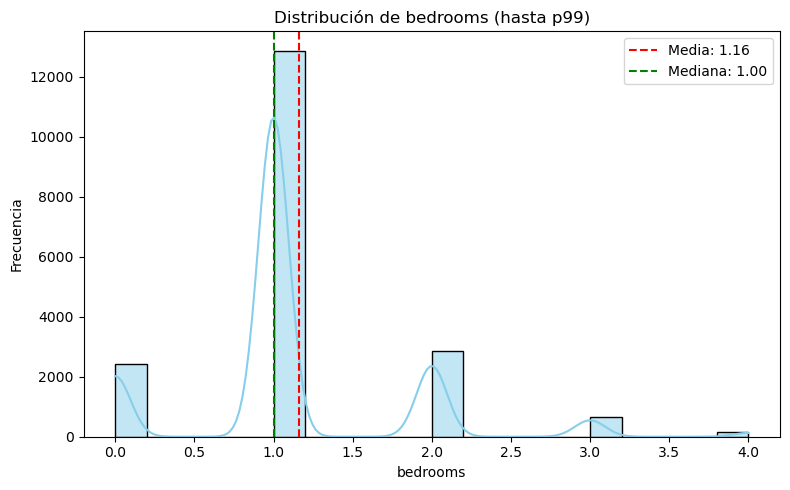

In [647]:
p99 = X_train['bedrooms'].quantile(0.99)
datos = X_train[X_train['bedrooms'] <= p99]['bedrooms'].dropna()

plt.figure(figsize=(8, 5))
sns.histplot(datos, bins=20, kde=True, color='skyblue')

media = X_train['bedrooms'].mean()
mediana = X_train['bedrooms'].median()
plt.axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
plt.legend()

plt.title('Distribución de bedrooms (hasta p99)')
plt.xlabel('bedrooms')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Mismo patro y conclusiones tomadas para maximum_night. PAtron multimodal y vamos a imputar por la mediana que es quien menos nos altera la destribucion de la variable.

Veamos ahora el comportamiento de las variables  beds y  bathrooms.

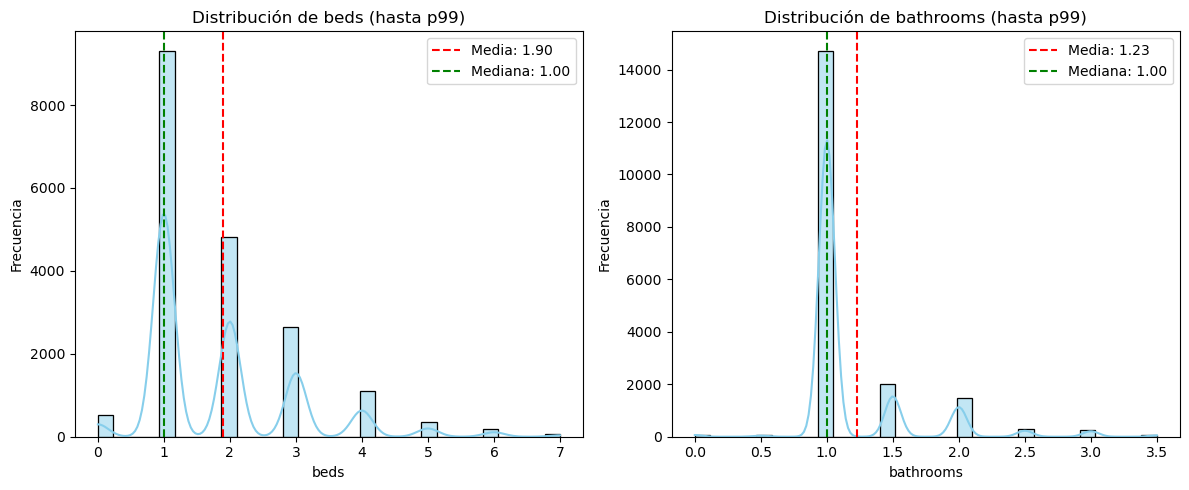

In [648]:
variables = ['beds', 'bathrooms']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(variables):
    p99 = X_train[var].quantile(0.99)
    datos = X_train[X_train[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    
    media = X_train[var].mean()
    mediana = X_train[var].median()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
    axes[i].legend()
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Vamos que en ambos casos son disribuciones multimodal y es conveniente imputar los valores faltantes por la mediana que es el valor que menos afectar la distribucion normal de las variables

Concluimos que todas las variables se imputan por la mediana

In [649]:
from sklearn.impute import SimpleImputer

columnas_imputar = [
    'review_scores_location', 'reviews_per_month', 'review_scores_rating',
    'maximum_nights', 'minimum_nights', 'maximum_maximum_nights',
    'maximum_minimum_nights', 'minimum_minimum_nights', 'minimum_maximum_nights',
    'bedrooms', 'beds', 'bathrooms'
]

imputer = SimpleImputer(strategy='median')

X_train[columnas_imputar] = imputer.fit_transform(X_train[columnas_imputar])
X_test[columnas_imputar] = imputer.transform(X_test[columnas_imputar])

# Verificar que no quedaron nulos
print(f"Nulos en X_train: {X_train.isnull().sum().sum()}")
print(f"Nulos en X_test: {X_test.isnull().sum().sum()}")

Nulos en X_train: 0
Nulos en X_test: 0


Por ultimo corroboramos que no hay mas valores ausentes.

#### Analicemos si existen outliers

In [650]:
X_train.describe()

,last_scraped,hosts_time_as_user_months,hosts_time_as_host_months,host_listings_count,host_has_profile_pic,latitude,longitude,accommodates,bathrooms,bedrooms,...,comuna_3,comuna_4,comuna_5,comuna_6,comuna_7,comuna_8,comuna_9,room_type_Hotel room,room_type_Private room,room_type_Shared room
count,19143,19143.0,19143.0,19143.0,19143.000000,19143.0,19143.0,19143.0,19143.000000,19143.000000,...,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000
mean,2026-01-25 11:35:26.375176,92.318393,66.802696,18.011597,0.966881,-34.592027,-58.416347,2.945359,1.227707,1.162827,...,0.043985,0.014836,0.040589,0.016664,0.006895,0.000104,0.002037,0.002873,0.083216,0.004545
min,2026-01-25 00:00:00,0.0,0.0,1.0,0.000000,-34.66774,-58.52792,1.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-01-25 00:00:00,45.0,28.0,1.0,1.000000,-34.60315,-58.435961,2.0,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2026-01-25 00:00:00,99.0,49.0,3.0,1.000000,-34.59135,-58.41841,2.0,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2026-01-26 00:00:00,128.0,100.0,16.0,1.000000,-34.581496,-58.391128,4.0,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2026-01-26 00:00:00,201.0,180.0,945.0,1.000000,-34.53621,-58.355403,16.0,20.000000,19.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,47.830703,47.564844,39.81634,0.178952,0.017876,0.029894,1.548722,0.666759,0.912465,...,0.205067,0.120898,0.197342,0.128013,0.082754,0.010221,0.045092,0.053526,0.276215,0.067263


Vamos analizar alguna variables que pueden taner valores maximas mas llamativos

=== TABLA DE PERCENTILES ===

--- host_listings_count ---
count      19143.0
mean     18.011597
std       39.81634
min            1.0
25%            1.0
50%            3.0
75%           16.0
90%           57.0
95%           91.0
99%          189.0
max          945.0
Name: host_listings_count, dtype: Float64

--- bathrooms ---
count    19143.000000
mean         1.227707
std          0.666759
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
90%          2.000000
95%          2.000000
99%          3.500000
max         20.000000
Name: bathrooms, dtype: float64

--- bedrooms ---
count    19143.000000
mean         1.162827
std          0.912465
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
90%          2.000000
95%          2.000000
99%          4.000000
max         19.000000
Name: bedrooms, dtype: float64

--- beds ---
count    19143.000000
mean         1.898083
std          1.506926
min          0.000000
25%  

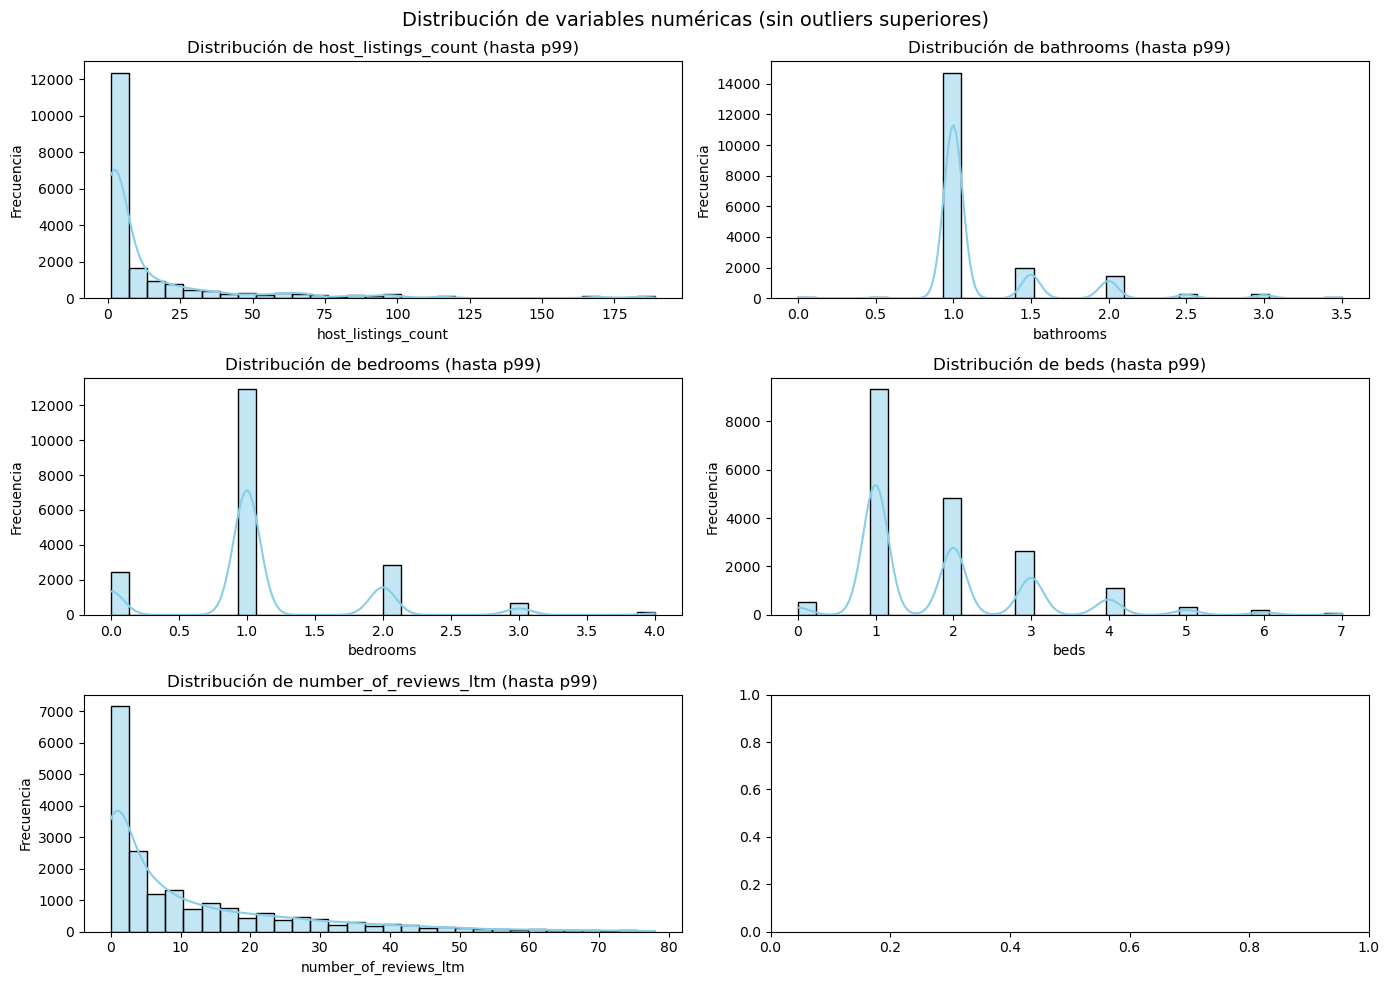

In [651]:
variables = ['host_listings_count', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews_ltm']

# Tabla de percentiles
print("=== TABLA DE PERCENTILES ===\n")
for var in variables:
    print(f"--- {var} ---")
    print(X_train[var].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
    print()

# Histogramas recortados por p99
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    p99 = X_train[var].quantile(0.99)
    datos = X_train[X_train[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas (sin outliers superiores)', fontsize=14)
plt.tight_layout()
plt.show()

Se observa en todas las variables que pueden tener algunos valores altos pero no son atipicos sino de huespedes especiales.
CONCLUSION NO SE ANULA NINGUN DATO POR OUTLIERS

Todavia tenemos variables que son numericas y tenemos que tomar un deceision, vemos que son variables que no aportan valor al target por su escencia:
last_scraped, Fecha de scraping
host_profile_url, URL del perfil
host_name,Nombre del anfitrión
host_picture_url, URL de la foto de perfil
calendar_last_scrapedFecha del último scraping del calendario

In [652]:
columnas_eliminar = ['last_scraped', 'host_profile_url', 'host_name', 
                     'host_picture_url', 'calendar_last_scraped']

X_train = X_train.drop(columns=columnas_eliminar, errors='ignore').copy()
X_test = X_test.drop(columns=columnas_eliminar, errors='ignore').copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (19143, 55)
X_test shape: (8205, 55)


Aunque Phi y point-biserial provienen de tradiciones estadísticas distintas (Chi-cuadrado para tablas de contingencia vs. correlación de Pearson), ambas 
se reducen matemáticamente a la misma fórmula cuando las dos variables son binarias (0/1) — Phi es simplemente Pearson aplicado a ese caso particular. 
Por eso usamos una sola función para calcular la asociación de todas las features (numéricas y binarias) contra el target.

In [653]:
from scipy import stats

def asociacion_con_target(X, y, col):
    valores_unicos = X[col].nunique()
    
    if valores_unicos < 2:
        return {'feature': col, 'tipo': 'constante', 'asociacion': np.nan, 'p_value': np.nan}
    
    try:
        corr, pvalue = stats.pointbiserialr(y, X[col])
    except Exception as e:
        return {'feature': col, 'tipo': 'error', 'asociacion': np.nan, 'p_value': np.nan}
    
    tipo = "Phi (binaria)" if valores_unicos == 2 else "Point-biserial (numerica)"
    
    return {'feature': col, 'tipo': tipo, 'asociacion': corr, 'p_value': pvalue}


resultados = []
for col in X_train.columns:
    if col in ['id', 'host_id']:
        continue
    resultados.append(asociacion_con_target(X_train, y_train, col))

resultados_df = pd.DataFrame(resultados)
resultados_df['asociacion_abs'] = resultados_df['asociacion'].abs()
resultados_df = resultados_df.sort_values('asociacion_abs', ascending=False)


def interpretar_asociacion(row):
    valor = row['asociacion']
    pvalue = row['p_value']
    
    if pd.isna(valor):
        return "no calculable"
    
    if pvalue >= 0.05:
        return "no significativa"
    
    v = abs(valor)
    if v < 0.1:
        return "significativa - débil"
    elif v < 0.3:
        return "significativa - débil-moderada"
    elif v < 0.5:
        return "significativa - moderada-fuerte"
    else:
        return "significativa - fuerte"

resultados_df['interpretacion'] = resultados_df.apply(interpretar_asociacion, axis=1)
print(resultados_df.to_string(index=False))

                                     feature                      tipo  asociacion       p_value  asociacion_abs                  interpretacion
                       number_of_reviews_ltm Point-biserial (numerica)    0.310650  0.000000e+00        0.310650 significativa - moderada-fuerte
                           reviews_per_month Point-biserial (numerica)    0.245802 2.178375e-261        0.245802  significativa - débil-moderada
                                        hair             Phi (binaria)    0.244608 8.496146e-259        0.244608  significativa - débil-moderada
                                       dryer             Phi (binaria)    0.237630 6.206677e-244        0.237630  significativa - débil-moderada
                                      coffee             Phi (binaria)    0.230256 9.475136e-229        0.230256  significativa - débil-moderada
                        review_scores_rating Point-biserial (numerica)    0.221887 3.710051e-212        0.221887  significativa - 

In [654]:
from scipy import stats

# ── Función de asociación ──────────────────────────────────────────────────
def asociacion_con_target(X, y, col):
    valores_unicos = X[col].nunique()
    
    if valores_unicos < 2:
        return {'feature': col, 'tipo': 'constante', 'asociacion': np.nan, 'p_value': np.nan}
    
    try:
        corr, pvalue = stats.pointbiserialr(y, X[col])
    except:
        return {'feature': col, 'tipo': 'error', 'asociacion': np.nan, 'p_value': np.nan}
    
    tipo = "Phi (binaria)" if valores_unicos == 2 else "Point-biserial (numerica)"
    return {'feature': col, 'tipo': tipo, 'asociacion': corr, 'p_value': pvalue}

# ── Calcular asociación para todas las columnas ────────────────────────────
resultados = []
for col in X_train.columns:
    if col in ['id', 'host_id']:
        continue
    resultados.append(asociacion_con_target(X_train, y_train, col))

resultados_df = pd.DataFrame(resultados)
resultados_df['asociacion_abs'] = resultados_df['asociacion'].abs()
resultados_df = resultados_df.sort_values('asociacion_abs', ascending=False)

# ── Interpretación ─────────────────────────────────────────────────────────
def interpretar_asociacion(row):
    if pd.isna(row['asociacion']): return "no calculable"
    if row['p_value'] >= 0.05: return "no significativa"
    v = abs(row['asociacion'])
    if v < 0.1:   return "significativa - débil"
    elif v < 0.3: return "significativa - débil-moderada"
    elif v < 0.5: return "significativa - moderada-fuerte"
    else:         return "significativa - fuerte"

resultados_df['interpretacion'] = resultados_df.apply(interpretar_asociacion, axis=1)
print(resultados_df.to_string(index=False))

# ── Filtrar y aplicar ──────────────────────────────────────────────────────
seleccionadas = resultados_df[resultados_df['p_value'] < 0.05]['feature'].tolist()
descartadas   = resultados_df[resultados_df['p_value'] >= 0.05]['feature'].tolist()

print(f"\nVariables seleccionadas: {len(seleccionadas)}")
print(f"Variables descartadas:   {len(descartadas)} → {descartadas}")



                                     feature                      tipo  asociacion       p_value  asociacion_abs                  interpretacion
                       number_of_reviews_ltm Point-biserial (numerica)    0.310650  0.000000e+00        0.310650 significativa - moderada-fuerte
                           reviews_per_month Point-biserial (numerica)    0.245802 2.178375e-261        0.245802  significativa - débil-moderada
                                        hair             Phi (binaria)    0.244608 8.496146e-259        0.244608  significativa - débil-moderada
                                       dryer             Phi (binaria)    0.237630 6.206677e-244        0.237630  significativa - débil-moderada
                                      coffee             Phi (binaria)    0.230256 9.475136e-229        0.230256  significativa - débil-moderada
                        review_scores_rating Point-biserial (numerica)    0.221887 3.710051e-212        0.221887  significativa - 

In [655]:
X_train = X_train[seleccionadas].copy()
X_test  = X_test[seleccionadas].copy()

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


X_train shape: (19143, 45)
X_test shape:  (8205, 45)


## JPC: La significancia estadistica tiene como requisito que los datos tengan __distribucion normal y que la varianza sea homogenea__, creo que punto biserial funcionan siempre. __Mutual Information__ tambien deberia funcionar

Para la selección de features, utilizamos como criterio la **significancia estadística** (p-value < 0.05) de la asociación entre cada feature y el target 
`host_is_superhost`, calculada mediante point-biserial/Phi según corresponda.
A diferencia de filtrar por la magnitud del coeficiente (que descartaría prácticamente todas las variables al ser, en su mayoría, asociaciones débiles), 
este criterio responde a la pregunta de si la asociación observada es estadísticamente distinguible del azar, independientemente de su tamaño

#### En el siguiente paso vamos a escalar  los valores

In [656]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit en train, transform en train y test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame manteniendo columnas e índices
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

X_train_scaled: (19143, 45)
X_test_scaled:  (8205, 45)


##### La variable target `host_is_superhost` presenta una distribución de 57.7% (0) y 42.3% (1), lo cual representa un dataset prácticamente balanceado. Por lo tanto, 
##### no es necesario aplicar técnicas de balanceo (SMOTE, undersampling, etc.). Adicionalmente, se utilizó `stratify=y` en el train/test split para preservar 
##### esta proporción tanto en el conjunto de entrenamiento como en el de test.

Avanzamos con la reduccion de dimencionalidad PCA

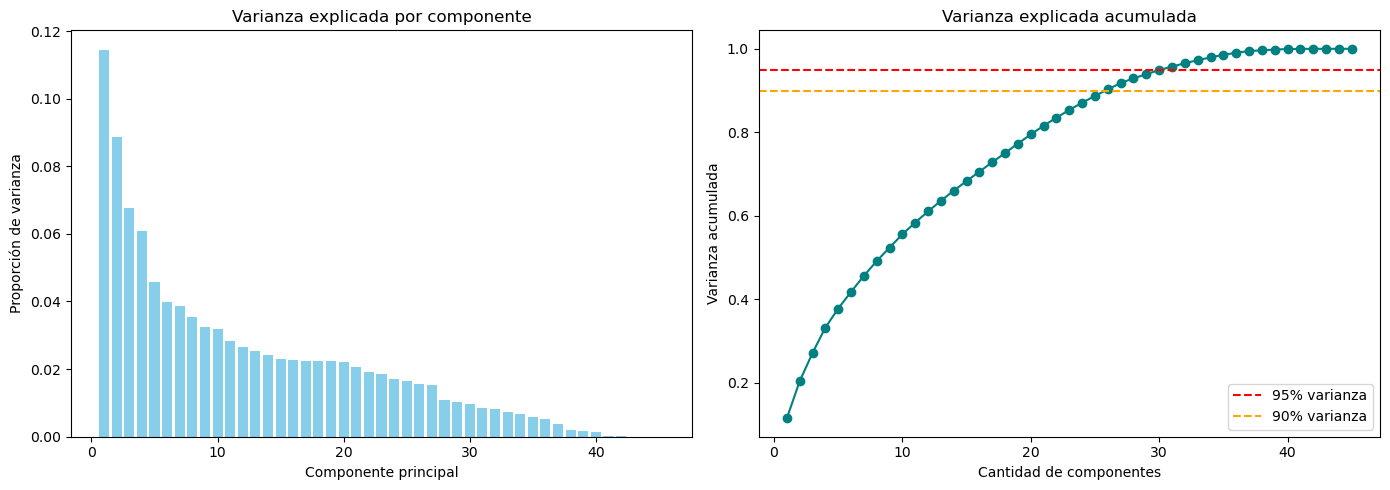

Componentes para 90% varianza: 26
Componentes para 95% varianza: 31


In [657]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Aplicar PCA sobre los datos escalados
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(varianza_explicada)+1), varianza_explicada, color='skyblue')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Proporción de varianza')

axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker='o', color='teal')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% varianza')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% varianza')
axes[1].set_title('Varianza explicada acumulada')
axes[1].set_xlabel('Cantidad de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Componentes para 90% varianza: {np.argmax(varianza_acumulada >= 0.90) + 1}")
print(f"Componentes para 95% varianza: {np.argmax(varianza_acumulada >= 0.95) + 1}")

El análisis de PCA muestra que la varianza está distribuida de forma relativamente uniforme entre las componentes principales, requiriendo 
27-28 de las 30 componentes originales para retener el 95% de la varianza. Esto indica baja redundancia entre las variables tras la selección de features 
previamente realizada, por lo que PCA no resulta una técnica efectiva para reducir significativamente la dimensionalidad en este caso sin una pérdida 
considerable de información.